# STARE-PODS — Rendezvous Analytics

*Companion notebook for the video walkthrough. Everything runs live against
**AWS S3** (Parquet chunks) + **RDS Postgres** (the `PodsMetadata` catalog);
the granules were ingested beforehand, so this notebook only queries.*

**STARE-PODS** — the **STARE Parallel Optimized Data Store** — leverages the
STARE quad-tree hierarchy to partition and organize geospatial data, and thus
enables distributed parallel processing of native data without requiring
re-gridding, i.e. resampling and/or re-projection.

For this demo of the STARE-PODS prototype, swaths of level 1C data from four
microwave radiometers — GPM's **GMI**, DMSP's **SSMIS**, GCOM-W1's **AMSR2**,
and JPSS's **ATMS** — were decomposed at STARE quadfurcation level 4
(**QL4** — the only name used for it from here on). This results in 2048
pods, corresponding to 2048 QL4 STARE spherical
triangles, or *trixels*, each roughly 700 km on a side, or an area of about
250,000 km² on average. The decomposition extracts the data elements of each swath that
overlap a given QL4 trixel and packages them into a Parquet chunk file —
so a pod (a logical construct) contains data chunks from **all** the swaths
that overlap (non-empty intersect) with the pod area: a natural spatial
co-location.

During the decomposition, a database management system (PostgreSQL)
catalogues all necessary information to reconstitute the swath granule — the
chunk's granule and pod identities, its space-time extents, etc., as well as
the metadata of the original HDF/netCDF file. Because the database holds the
chunks' spatiotemporal information, it can serve as a cross-instrument
**rendezvous engine**.

The store holds the **first quarter of 2025** — every Level 1C granule of
the four instruments from January 1 to March 31, about 7,400 granules
decomposed into 12.5 million chunks. Every part runs on that whole
quarter, with one set of time windows throughout — **Δt = 5, 10 and 30
minutes**. Parts 1, 2 and 6 are the statistics; Parts 3, 4 and 5 bring
them down to the ground: a rendezvous over **Virginia**, the orbit swaths
that make it, and a region query over the whole state.

1. **The temporal catalog** — every chunk knows *where* and *when* (the quarter)
2. **Rendezvous analytics** — who met whom, over the whole quarter
3. **Rendezvous over Virginia** — the pod holding most of the state, its rendezvous, six example orbit swaths
4. **Rendezvous up close** — all six passes over the pod, then the three that meet within 5 minutes
5. **Rendezvous over a region of interest** — Virginia: space and time in one query
6. **Performance at scale** — the whole quarter, timed at four scopes


In [1]:
import time
_setup_t0 = time.perf_counter()          # so this setup cell is timed too
from IPython import get_ipython

# Per-cell timing: every later cell self-reports "⏱ cell [n] took X.XXs" and
# the summary cell at the end totals them. Registered by name so re-running
# this cell cannot stack duplicate hooks.
CELL_TIMINGS = {}
_cell_start = {}


def _time_pre(info):
    _cell_start['t0'] = time.perf_counter()


def _time_post(result):
    t0 = _cell_start.pop('t0', None)
    if t0 is None:                       # cell failed before pre_run_cell ran
        return
    elapsed = time.perf_counter() - t0
    CELL_TIMINGS[result.execution_count] = elapsed
    print(f"\u23f1  cell [{result.execution_count}] took {elapsed:.2f}s")


_ip = get_ipython()
for _event, _fn in (('pre_run_cell', _time_pre), ('post_run_cell', _time_post)):
    for _old in [f for f in _ip.events.callbacks[_event] if f.__name__ == _fn.__name__]:
        _ip.events.unregister(_event, _old)
    _ip.events.register(_event, _fn)
_cell_start['t0'] = _setup_t0

import logging
import re
import os
from contextlib import contextmanager
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from great_tables import loc, style
from great_tables import GT as _GT


def GT(frame, **kwargs):
    """great_tables.GT, house-styled: bold centered title, centered subtitle
    (inline styles, so the notebook viewer's own table CSS cannot override
    them), and plain-word column labels auto-capitalized — code identifiers
    such as t_start keep their spelling."""
    table = (_GT(frame, **kwargs)
             .tab_style(style=style.text(align='center', weight='bold'),
                        locations=loc.title())
             .tab_style(style=style.text(align='center'),
                        locations=loc.subtitle()))
    labels = {c: c[0].upper() + c[1:] for c in frame.columns
              if isinstance(c, str) and re.fullmatch(r'[a-z][a-z ]*', c)}
    if labels:
        table = table.cols_label(labels)
    return table

logging.getLogger('starepandas').setLevel(logging.WARNING)  # keep outputs clean

import starepandas
from starepandas.demo_lib import StarePodsDemo
from starepandas.staredataframe import parse_chunk_filename, sid_to_podcode
from starepandas.io.granules import (
    load_s3_catalog_summary, load_s3_metadata, load_s3_pod_occupancy,
    load_s3_temporal_catalog,
)
from starepandas.overlap import (
    rendezvous_events, overlap_matrix, overlap_pod_table, pod_drilldown,
    fold_instrument,
)
from starepandas.demo_plots import (
    SATELLITES as SWATH_SATELLITES, chunk_pixels, plot_pod_coverage,
    plot_region_cover, plot_region_result, plot_rendezvous, pod_trixels,
    swath_pixels,
)

CONFIG_PATH = os.path.join(
    os.path.dirname(os.path.abspath(starepandas.__file__)), ".config")
STORE_PREFIX = "s3://zarrpods/storage"          # the Q1-2025 bulk-store root (scan-group list, Part 6)
WINDOWS = tuple(pd.Timedelta(minutes=m) for m in (5, 10, 30))   # the Δt windows, every part
STARE_LEVEL = 4
INSTRUMENTS = ["GMI", "SSMIS", "AMSR2", "ATMS"]


class StepTimer:
    """Sub-step stopwatch for one cell: ``with T.step(kind, what): ...``
    records wall-clock seconds per step, tagged by kind — ``query`` (the
    database or S3 listing answers), ``download`` (chunk bytes from S3),
    ``local`` (pandas / STARE work on this computer), ``plot`` (building a
    matplotlib figure) and ``display`` (rendering a table or figure into the
    notebook). ``T.table()`` shows the breakdown with per-kind totals."""

    def __init__(self):
        self.steps = []
        self.last = None

    @contextmanager
    def step(self, kind, what):
        t0 = time.perf_counter()
        yield
        self.last = time.perf_counter() - t0
        self.steps.append({'kind': kind, 'step': what, 'seconds': self.last})

    def frame(self):
        df = pd.DataFrame(self.steps)
        df['share'] = df['seconds'] / df['seconds'].sum()
        return df

    def table(self, title):
        df = self.frame()
        return (GT(df)
                .tab_header(title=title,
                            subtitle=f"{df['seconds'].sum():.1f} s over "
                                     f"{len(df)} steps, in the order they ran")
                .fmt_number(columns='seconds', decimals=2)
                .fmt_percent(columns='share', decimals=0)
                .cols_label(kind="", step="", seconds="Seconds", share="Share"))


def fmt_times(frame, columns=('t_start', 't_end')):
    """Render timestamp columns as compact strings for table display."""
    out = frame.copy()
    for column in columns:
        out[column] = out[column].dt.strftime('%Y-%m-%d %H:%M:%S')
    return out


demo = StarePodsDemo(aws_config_path=CONFIG_PATH)


def minutes_of(dt):
    return int(dt.total_seconds() // 60)


⏱  cell [1] took 2.21s


## Data Ingested in STARE-PODS

The store holds the **first quarter of 2025** for the four instruments —
every Level 1C granule of GMI, SSMIS, AMSR2 and ATMS from January 1 to
March 31, ATMS on all three of its satellites (Suomi NPP, NOAA-20, NOAA-21).
Level 1C means intercalibrated brightness temperatures (`Tc`) on the GPM
XCAL common calibration. Each granule is decomposed **scan group** by scan
group (a scan group is what the catalog calls a *dataset*: one instrument's
swath at one footprint size, `GMI_S1`, `SSMIS_S4`, …), so a granule of a
four-scan-group instrument yields four families of chunks.

Every fact in the table below is read straight back from the catalog and
aggregated **by the database**: a quarter is twelve million chunk records,
far more than a notebook should pull down in full — Part 2 will read just
four columns of them. The chunk file names preserve
the original granule identity, e.g.

`1C.F18.SSMIS.XCAL2021-V.20250101-S112813-E131004.078441.V07B`

(level · satellite · instrument · intercalibration · sensing span · orbit ·
product version), so each chunk's satellite is recoverable from its path.
Every part of this notebook runs on this whole quarter.


In [2]:
# Two server-side views of the whole catalog, no chunk records transferred:
#   summary   — one row per storage root x scan group x platform (a full pass over
#               the catalog: granules, chunks, pods, sensing span)
#   occupancy — chunks per scan group x pod (served from the covering index)
from IPython.display import HTML
from great_tables import html

T = StepTimer()
with T.step('query', 'catalog summary — the database\'s one full read of the quarter'):
    summary = load_s3_catalog_summary()
t_summary = T.last
with T.step('query', 'pod occupancy — chunks per scan group × pod, index-only'):
    occupancy = load_s3_pod_occupancy()
t_occupancy = T.last

with T.step('local', 'fold scan groups to instruments, cross-check the two views'):
    assert summary['chunks'].sum() == occupancy['chunks'].sum()   # one catalog, two views
    summary['instrument'] = summary['Dataset'].map(fold_instrument)
    occupancy['instrument'] = occupancy['Dataset'].map(fold_instrument)

SATELLITES = {'GPM': 'GPM Core Observatory', 'F18': 'DMSP F18', 'GCOMW1': 'GCOM-W1',
              'NPP': 'Suomi NPP', 'NOAA20': 'NOAA-20 (JPSS-1)', 'NOAA21': 'NOAA-21 (JPSS-2)'}
L1C_CHANNELS = {'GMI': 13, 'SSMIS': 11, 'AMSR2': 12, 'ATMS': 9}


def satellite_list(platforms):
    """Satellite names, comma-separated, continued on a second line after
    the second one so a three-platform row (ATMS) keeps the table narrow."""
    order = ['GPM', 'F18', 'GCOMW1', 'NPP', 'NOAA20', 'NOAA21']          # launch order
    names = [SATELLITES.get(p, p) for p in sorted(platforms, key=lambda p: (order.index(p) if p in order else 99, p))]
    return ', '.join(names[:2]) + (',<br>' + ', '.join(names[2:]) if len(names) > 2 else '')


def granule_count(frame):
    """Granules in a summary slice. Every scan group of a granule is its own
    summary row, so a (root, platform) is counted once — the widest of its
    scan groups — then summed: roots are disjoint, platforms are different
    satellites."""
    return int(frame.groupby(['storage_root', 'platform'], dropna=False)['granules']
                    .max().sum())


with T.step('local', 'inventory rows per instrument (pandas over 42 + 32,624 rows)'):
    rows = []
    for instrument in INSTRUMENTS:
        sub = summary[summary['instrument'] == instrument]
        store_groups = sorted(d.split('_', 1)[1]
                              for d in sub.loc[sub['storage_root'] == STORE_PREFIX, 'Dataset'].unique())
        platforms = sorted(sub['platform'].dropna().unique())
        rows.append({
            'instrument': instrument,
            'satellites': satellite_list(platforms),
            'channels': L1C_CHANNELS[instrument],
            'scan_groups': f"{len(store_groups)} ({store_groups[0]}–{store_groups[-1]})",
            'granules': granule_count(sub),
            'chunks': int(sub['chunks'].sum()),
            'pods': occupancy.loc[occupancy['instrument'] == instrument, 'podcode'].nunique(),
        })
    inventory = pd.DataFrame(rows)
with T.step('display', 'render "Current PODS Holdings"'):
    display(HTML('<p style="text-align:center;margin:0.5em 0 0">'
                 'Period: 2025-01-01 to 2025-03-31 (2025Q1)</p>'))
    display(
        GT(inventory)
        .tab_header(title="Current PODS Holdings — 2025Q1 by Instrument",
                    subtitle=html(f"<b>{granule_count(summary):,} granules → "
                                  f"{summary['Dataset'].nunique()} scan groups → "
                                  f"{summary['chunks'].sum():,} chunks in "
                                  f"{occupancy['podcode'].nunique()} QL4 pods</b> "
                                  f"(query time {t_summary:.0f} s + {t_occupancy:.0f} s)"))
        .fmt_integer(columns=['granules', 'chunks'])
        .fmt_markdown(columns=['satellites'])
        .cols_label(channels="L1C channels", scan_groups="Scan groups")
        .tab_source_note("channel counts per the GPM V07 file specification; "
                         "the bulk store carries ATMS S1–S4; a small 2025-01-01 test "
                         "root carries S1–S2 only; pods = distinct QL4 pods across all "
                         "of an instrument's chunks")
    )

display(T.table("Processing Time of Each Step in this Notebook Cell"))


GT(_tbl_data=  instrument                                        satellites  channels  \
0        GMI                              GPM Core Observatory        13   
1      SSMIS                                          DMSP F18        11   
2      AMSR2                                           GCOM-W1        12   
3       ATMS  Suomi NPP, NOAA-20 (JPSS-1),<br>NOAA-21 (JPSS-2)         9   

  scan_groups  granules   chunks  pods  
0   2 (S1–S2)      1387   751129  1980  
1   4 (S1–S4)      1267  1898057  2048  
2   6 (S1–S6)      1310  2891241  2048  
3   4 (S1–S4)      3396  6911440  2048  , _body=<great_tables._gt_data.Body object at 0x17ced5880>, _boxhead=Boxhead([ColInfo(var='instrument', type=<ColInfoTypeEnum.default: 1>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='satellites', type=<ColInfoTypeEnum.default: 1>, column_label='Satellites', column_align='left', column_width=None), ColInfo(var='channels', type=<ColInfoTypeEnum.default: 1>, column_label='L1C channels', column_align='right', column_width=None), ColInfo(var='scan_groups', type=<ColInfoTypeEnum.default: 1>, column_label='Scan groups', column_align='left', column_width=None), ColInfo(var='granules', type=<ColInfoTypeEnum.default: 1>, column_label='Granules', column_align='right', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label='Chunks', column_align='right', column_width=None), ColInfo(var='pods', type=<ColInfoTypeEnum.default: 1>, column_label='Pods', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x340feaa50>, _spanners=Spanners([]), _heading=Heading(title='Current PODS Holdings — 2025Q1 by Instrument', subtitle=Html(text='<b>7,360 granules → 16 scan groups → 12,451,867 chunks in 2048 QL4 pods</b> (query time 103 s + 5 s)'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x340fea870>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x340fea7e0>, _source_notes=["channel counts per the GPM V07 file specification; the bulk store carries ATMS S1–S4; a small 2025-01-01 test root carries S1–S2 only; pods = distinct QL4 pods across all of an instrument's chunks"], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x340fea810>, _formats=[<great_tables._gt_data.FormatInfo object at 0x340febbf0>, <great_tables._gt_data.FormatInfo object at 0x340fe9ac0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(

GT(_tbl_data=      kind                                               step     seconds  \
0    query  catalog summary — the database's one full read...  103.236552   
1    query  pod occupancy — chunks per scan group × pod, i...    4.838129   
2    local  fold scan groups to instruments, cross-check t...    0.020539   
3    local  inventory rows per instrument (pandas over 42 ...    0.009564   
4  display                     render "Current PODS Holdings"    0.015710   

      share  
0  0.954829  
1  0.044748  
2  0.000190  
3  0.000088  
4  0.000145  , _body=<great_tables._gt_data.Body object at 0x340fea690>, _boxhead=Boxhead([ColInfo(var='kind', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='step', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='seconds', type=<ColInfoTypeEnum.default: 1>, column_label='Seconds', column_align='right', column_width=None), ColInfo(var='share', type=<ColInfoTypeEnum.default: 1>, column_label='Share', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x340fea810>, _spanners=Spanners([]), _heading=Heading(title='Processing Time of Each Step in this Notebook Cell', subtitle='108.1 s over 5 steps, in the order they ran', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x340feb170>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x340fe8080>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x340fe8b30>, _formats=[<great_tables._gt_data.FormatInfo object at 0x340fe9490>, <great_tables._gt_data.FormatInfo object at 0x340feb530>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_to

⏱  cell [2] took 108.13s


## Part 1 — The temporal catalog

When a granule is decomposed, the database records the start and end times of
every chunk — `t_start` and `t_end`, the earliest and latest **scan times of
the data elements inside the chunk** — together with the chunk's spatial
address, the **pod code**: the chunk's STARE index written as a quaternary
(base-4) number. Like STARE indices, pod codes encode STARE's quad-tree
hierarchy — each digit refines the previous, similar to a postal code. The
scan times are actual times extracted from the granule's content, **not** the
time in the granule's file name.

Over the quarter that is 12.5 million such records. The two tables are the
database's own aggregates of them — per scan group, then per pod, with the
emptiest, the median and the fullest pod located on the globe.


In [3]:
per_ds = (summary.groupby('Dataset', as_index=False)
          .agg(chunks=('chunks', 'sum'),
               first_start=('t_start', 'min'),
               last_end=('t_end', 'max')))
per_ds.insert(1, 'granules', per_ds['Dataset'].map(
    lambda d: granule_count(summary[summary['Dataset'] == d])))
per_ds.insert(3, 'pods', per_ds['Dataset'].map(
    occupancy.groupby('Dataset')['podcode'].nunique()))
per_ds.insert(0, 'instrument', per_ds['Dataset'].map(fold_instrument))   # row groups


# every scan group of an instrument shares its first t_start / last t_end:
# show each once, on the group's first row
shown = fmt_times(per_ds, ('first_start', 'last_end'))
repeat = shown.duplicated(['instrument', 'first_start', 'last_end'])
shown.loc[repeat, ['first_start', 'last_end']] = ''
temporal_table = (
    GT(shown,
       groupname_col='instrument', rowname_col='Dataset')
    .tab_header(title="Temporal Catalog per Scan Group for 2025Q1",
                subtitle=html(f"<b>Total {summary['chunks'].sum():,} chunks</b>"))
    .fmt_integer(columns=['granules', 'chunks'])
    .cols_label(first_start="First t_start", last_end="Last t_end")
    .tab_style(style=style.text(weight='bold'), locations=loc.row_groups())
)
display(temporal_table)


def locate(podcode):
    """Centre of a pod's trixel as 'lat, lon (band)' — the polar pods are
    split at the antimeridian, so use the geometry's centroid."""
    centre = pod_trixels([podcode]).union_all().centroid
    lat, lon = centre.y, centre.x
    band = ('polar' if abs(lat) > 66.5 else
            'mid-latitude' if abs(lat) > 23.5 else 'tropical')
    return (f"{abs(lat):.0f}°{'N' if lat >= 0 else 'S'} "
            f"{abs(lon):.0f}°{'E' if lon >= 0 else 'W'}, {band}")


pod_chunks = occupancy.groupby('podcode')['chunks'].sum()
pod_instruments = occupancy.groupby('podcode')['instrument'].nunique()
n_possible = 8 * 4 ** STARE_LEVEL            # 8 octants x 4^level trixels
emptiest = pod_chunks.idxmin()
median_pod = (pod_chunks - pod_chunks.median()).abs().idxmin()   # nearest to the median
busiest = pod_chunks.idxmax()
occupancy_q = pd.DataFrame([
    {'statistic': f'QL{STARE_LEVEL} pods on the globe', 'value': f'{n_possible}', 'where': '', 'geolocation': ''},
    {'statistic': 'Pods holding at least one chunk',
     'value': f'{len(pod_chunks)} ({len(pod_chunks) / n_possible:.0%})', 'where': '', 'geolocation': ''},
    {'statistic': 'Pods visited by all four instruments',
     'value': f'{int((pod_instruments == 4).sum())}', 'where': '', 'geolocation': ''},
    {'statistic': "Pods beyond the reach of GPM's 65° orbit",
     'value': f"{n_possible - occupancy.loc[occupancy['instrument'] == 'GMI', 'podcode'].nunique()}",
     'where': '', 'geolocation': 'the two polar caps'},
    {'statistic': 'Fewest chunks in a pod',
     'value': f'{pod_chunks.min():,}', 'where': emptiest, 'geolocation': locate(emptiest)},
    {'statistic': 'Median chunks per pod',
     'value': f'{pod_chunks.median():,.0f}', 'where': f'{median_pod} *', 'geolocation': locate(median_pod)},
    {'statistic': 'Most chunks in one pod',
     'value': f'{pod_chunks.max():,}', 'where': busiest, 'geolocation': locate(busiest)},
])
occupancy_table = (
    GT(occupancy_q)
    .tab_header(title=f"Pod Occupancy at QL{STARE_LEVEL} for 2025Q1",
                subtitle=html(f"<b>How the {summary['chunks'].sum():,} chunks spread over the "
                              f"QL{STARE_LEVEL} pods</b>"))
    .cols_label(statistic="", value="Number of pods/chunks", where="Where", geolocation="Geolocation")
    .cols_align(align='right', columns=['value'])
    .tab_source_note(f"* the pod nearest the median, with {pod_chunks[median_pod]:,} chunks; "
                     "geolocation = the centre of the pod's trixel. Sparsest near the "
                     "equator, where orbits are farthest apart; fullest at the poles, "
                     "where every sun-synchronous orbit converges")
)
# centred on the page with a plain HTML attribute, which survives viewers
# that drop the table's own stylesheet
display(HTML(f'<div align="center">{occupancy_table.as_raw_html()}</div>'))


GT(_tbl_data=   instrument   Dataset  granules   chunks  pods          first_start  \
0       AMSR2  AMSR2_S1      1310   482886  2048  2025-01-01 00:32:38   
1       AMSR2  AMSR2_S2      1310   482482  2048                        
2       AMSR2  AMSR2_S3      1310   482435  2048                        
3       AMSR2  AMSR2_S4      1310   482380  2048                        
4       AMSR2  AMSR2_S5      1310   483095  2048                        
5       AMSR2  AMSR2_S6      1310   477963  2048                        
6        ATMS   ATMS_S1      3396  1728857  2048  2025-01-01 00:47:01   
7        ATMS   ATMS_S2      3396  1728848  2048                        
8        ATMS   ATMS_S3      3395  1727694  2048                        
9        ATMS   ATMS_S4      3395  1726041  2048                        
10        GMI    GMI_S1      1387   388731  1980  2025-01-01 00:37:21   
11        GMI    GMI_S2      1387   362398  1972                        
12      SSMIS  SSMIS_S1      1267   476257  2048  2025-01-01 01:17:03   
13      SSMIS  SSMIS_S2      1267   476075  2048                        
14      SSMIS  SSMIS_S3      1267   471149  2048                        
15      SSMIS  SSMIS_S4      1267   474576  2048                        

               last_end  
0   2025-04-01 01:07:27  
1                        
2                        
3                        
4                        
5                        
6   2025-04-01 00:59:04  
7                        
8                        
9                        
10  2025-04-01 00:33:47  
11                       
12  2025-04-01 00:41:51  
13                       
14                       
15                       , _body=<great_tables._gt_data.Body object at 0x104622d80>, _boxhead=Boxhead([ColInfo(var='instrument', type=<ColInfoTypeEnum.row_group: 3>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='Dataset', type=<ColInfoTypeEnum.stub: 2>, column_label='Dataset', column_align='left', column_width=None), ColInfo(var='granules', type=<ColInfoTypeEnum.default: 1>, column_label='Granules', column_align='right', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label='Chunks', column_align='right', column_width=None), ColInfo(var='pods', type=<ColInfoTypeEnum.default: 1>, column_label='Pods', column_align='right', column_width=None), ColInfo(var='first_start', type=<ColInfoTypeEnum.default: 1>, column_label='First t_start', column_align='right', column_width=None), ColInfo(var='last_end', type=<ColInfoTypeEnum.default: 1>, column_label='Last t_end', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x340feaed0>, _spanners=Spanners([]), _heading=Heading(title='Temporal Catalog per Scan Group for 2025Q1', subtitle=Html(text='<b>Total 12,451,867 chunks</b>'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x104622900>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x1046228a0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocRowGroups(rows=None), grpname={'SSMIS', 'AMSR2', 'GMI', 'ATMS'}, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x104622870>, _formats=[<great_tables._

⏱  cell [3] took 0.04s


## Part 2 — Rendezvous analytics

Whether gridded, swath, or point data — once decomposed and distributed into
STARE-PODS, rendezvous analytics becomes straightforward. In fact it runs on
the **database records alone**, without needing to open and read the chunks.
A **rendezvous** here is a visit to the same pod area within a given time
window, **Δt**, by two or more instruments.

This part runs on the **whole quarter**: one read of four columns of the entire
catalog — pod code, scan group, `t_start`, `t_end` for every one of the
12.5 million chunks — and then everything is computed here, in memory.
Watch what happens as the window widens from 5 to 30 minutes, then who met
whom over three months within 10 minutes, and finally everything that met,
within those 10 minutes, in the pod where all four instruments came
together most often.


In [4]:
T = StepTimer()
PART2_DT = WINDOWS[1]                           # 10 min: the window for the matrix + drill-down
PART2_MIN = minutes_of(PART2_DT)
with T.step('query', 'read 4 columns of the whole catalog — 12.5 M chunks'):
    quarter = load_s3_temporal_catalog()          # no path_prefix: all three roots

sweep_rows = []
for dt in WINDOWS:
    minutes = minutes_of(dt)
    with T.step('local', f'find meetings + pod table at Δt = {minutes} min'):
        ev = rendezvous_events(quarter, dt)
        table = overlap_pod_table(ev)
    row = {'window': f"Δt = {minutes} min", 'events': len(ev)}
    for n in table.columns:
        row[f'{n}-way'] = int(table[n].gt(0).sum())
    sweep_rows.append(row)
    if dt == PART2_DT:
        q_events, q_pod_table = ev, table
    del ev, table
sweep = pd.DataFrame(sweep_rows)
way_cols = [col for col in sweep.columns if col.endswith('-way')]
sweep[way_cols] = sweep[way_cols].fillna(0).astype(int)
with T.step('display', 'render the Δt table'):
    display(
        GT(sweep)
        .tab_header(title="Time-Window Dependence of Rendezvous",
                    subtitle=f"{len(quarter):,} chunks in {quarter['podcode'].nunique()} "
                             "QL4 pods, 2025Q1; the window Δt widens from 5 to 30 minutes")
        .fmt_integer(columns=['events'])
        .tab_spanner(label="QL4 Pods with an n-way Rendezvous", columns=way_cols)
        .cols_label(window="")
    )

with T.step('local', 'pair matrix over the quarter'):
    q_matrix = overlap_matrix(q_events).astype(object)
    for instrument in q_matrix.index:          # the diagonal is not a pairing
        q_matrix.loc[instrument, instrument] = '—'
    q_matrix.insert(0, 'instrument', q_matrix.index)
with T.step('display', 'render the matrix'):
    display(
        GT(q_matrix.reset_index(drop=True), rowname_col='instrument')
        .tab_header(title=f"Pairwise Rendezvous with a {PART2_MIN}-min Window",
                    subtitle=f"pods where each pair rendezvous, of {8 * 4 ** STARE_LEVEL} QL{STARE_LEVEL} "
                             "pods; AMSR2 and ATMS are near-co-orbiting and meet "
                             "everywhere, GMI meets everyone in nearly every pod its "
                             "65° orbit reaches, SSMIS's orbital plane keeps it apart from "
                             "AMSR2 and ATMS (it still meets GMI, whose orbit drifts through "
                             "every local time)")
    )

with T.step('local', 'find the pod with the most 4-way rendezvous, drill into it'):
    widest_q = max(q_pod_table.columns)
    n_quad = int(q_pod_table[widest_q].gt(0).sum())
    q_events['width'] = q_events['instruments'].map(len)
    quad_counts = q_events.loc[q_events['width'] == widest_q, 'podcode'].value_counts()
    quad_pod = quad_counts.index[0]
    q_drill = pod_drilldown(q_events, quad_pod).drop(columns='times')
    q_drill = q_drill.assign(instruments=q_drill['instruments'].map(' + '.join))
with T.step('display', 'render the drill-down'):
    display(
        GT(q_drill)
        .tab_header(title=f"Rendezvous of All Instrument Combinations in Pod {quad_pod}",
                    subtitle=f"the pod with the most 4-way rendezvous within {PART2_MIN} minutes "
                             f"({quad_counts.iloc[0]}), one of {n_quad} such pods")
        .tab_source_note("every pair, every three-way combination and the full 4-way, "
                         "with how often each happened in three months; a combination "
                         "only counts when all its members are there simultaneously; "
                         f"the pod sits at {locate(quad_pod)}")
        .cols_label(instruments="Combination", n_instruments="n",
                    frequency="Rendezvous")
        # left-aligned throughout, like the two tables above it
        .cols_align(align='left', columns=['instruments', 'n_instruments', 'frequency'])
    )
del quarter
display(T.table("Processing Time of Each Step in this Part 2 Cell"))


GT(_tbl_data=        window   events  2-way  3-way  4-way
0   Δt = 5 min  1499727   2048   1414     19
1  Δt = 10 min  2338290   2048   1983     65
2  Δt = 30 min  5104738   2048   2048    390, _body=<great_tables._gt_data.Body object at 0x340f64d10>, _boxhead=Boxhead([ColInfo(var='window', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='events', type=<ColInfoTypeEnum.default: 1>, column_label='Events', column_align='right', column_width=None), ColInfo(var='2-way', type=<ColInfoTypeEnum.default: 1>, column_label='2-way', column_align='right', column_width=None), ColInfo(var='3-way', type=<ColInfoTypeEnum.default: 1>, column_label='3-way', column_align='right', column_width=None), ColInfo(var='4-way', type=<ColInfoTypeEnum.default: 1>, column_label='4-way', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x340f65790>, _spanners=Spanners([SpannerInfo(spanner_id='QL4 Pods with an n-way Rendezvous', spanner_level=0, spanner_label='QL4 Pods with an n-way Rendezvous', spanner_units=None, spanner_pattern=None, vars=['2-way', '3-way', '4-way'], built=None)]), _heading=Heading(title='Time-Window Dependence of Rendezvous', subtitle='12,451,867 chunks in 2048 QL4 pods, 2025Q1; the window Δt widens from 5 to 30 minutes', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x340f67290>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x340f665d0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x340f67500>, _formats=[<great_tables._gt_data.FormatInfo object at 0x340f67320>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='

GT(_tbl_data=  instrument AMSR2  ATMS   GMI SSMIS
0      AMSR2     —  2048  1976   473
1       ATMS  2048     —  1980   653
2        GMI  1976  1980     —  1963
3      SSMIS   473   653  1963     —, _body=<great_tables._gt_data.Body object at 0x340f3aa80>, _boxhead=Boxhead([ColInfo(var='instrument', type=<ColInfoTypeEnum.stub: 2>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='AMSR2', type=<ColInfoTypeEnum.default: 1>, column_label='AMSR2', column_align='left', column_width=None), ColInfo(var='ATMS', type=<ColInfoTypeEnum.default: 1>, column_label='ATMS', column_align='left', column_width=None), ColInfo(var='GMI', type=<ColInfoTypeEnum.default: 1>, column_label='GMI', column_align='left', column_width=None), ColInfo(var='SSMIS', type=<ColInfoTypeEnum.default: 1>, column_label='SSMIS', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x340f3af90>, _spanners=Spanners([]), _heading=Heading(title='Pairwise Rendezvous with a 10-min Window', subtitle="pods where each pair rendezvous, of 2048 QL4 pods; AMSR2 and ATMS are near-co-orbiting and meet everywhere, GMI meets everyone in nearly every pod its 65° orbit reaches, SSMIS's orbital plane keeps it apart from AMSR2 and ATMS (it still meets GMI, whose orbit drifts through every local time)", preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x340f38260>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x340f3a0f0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x340f3b5f0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=Optio

GT(_tbl_data=                   instruments  n_instruments  frequency
0                 AMSR2 + ATMS              2       4975
1                  AMSR2 + GMI              2        117
2                AMSR2 + SSMIS              2       2459
3                   ATMS + GMI              2        184
4                 ATMS + SSMIS              2       3693
5                  GMI + SSMIS              2        100
6           AMSR2 + ATMS + GMI              3        117
7         AMSR2 + ATMS + SSMIS              3       3295
8          AMSR2 + GMI + SSMIS              3         73
9           ATMS + GMI + SSMIS              3        101
10  AMSR2 + ATMS + GMI + SSMIS              4         87, _body=<great_tables._gt_data.Body object at 0x340f39790>, _boxhead=Boxhead([ColInfo(var='instruments', type=<ColInfoTypeEnum.default: 1>, column_label='Combination', column_align='left', column_width=None), ColInfo(var='n_instruments', type=<ColInfoTypeEnum.default: 1>, column_label='n', column_align='left', column_width=None), ColInfo(var='frequency', type=<ColInfoTypeEnum.default: 1>, column_label='Rendezvous', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x340f387a0>, _spanners=Spanners([]), _heading=Heading(title='Rendezvous of All Instrument Combinations in Pod q033303', subtitle='the pod with the most 4-way rendezvous within 10 minutes (87), one of 65 such pods', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x340f3b440>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x340f3b290>, _source_notes=['every pair, every three-way combination and the full 4-way, with how often each happened in three months; a combination only counts when all its members are there simultaneously; the pod sits at 73°S 75°W, polar'], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x340f398e0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table

GT(_tbl_data=      kind                                               step    seconds  \
0    query  read 4 columns of the whole catalog — 12.5 M c...  38.629779   
1    local            find meetings + pod table at Δt = 5 min  13.561396   
2    local           find meetings + pod table at Δt = 10 min  13.357512   
3    local           find meetings + pod table at Δt = 30 min  13.855876   
4  display                                render the Δt table   0.134983   
5    local                       pair matrix over the quarter   1.624901   
6  display                                  render the matrix   0.011389   
7    local  find the pod with the most 4-way rendezvous, d...   0.424544   
8  display                              render the drill-down   0.007689   

      share  
0  0.473357  
1  0.166177  
2  0.163679  
3  0.169786  
4  0.001654  
5  0.019911  
6  0.000140  
7  0.005202  
8  0.000094  , _body=<great_tables._gt_data.Body object at 0x340f38860>, _boxhead=Boxhead([ColInfo(var='kind', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='step', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='seconds', type=<ColInfoTypeEnum.default: 1>, column_label='Seconds', column_align='right', column_width=None), ColInfo(var='share', type=<ColInfoTypeEnum.default: 1>, column_label='Share', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3406a7e90>, _spanners=Spanners([]), _heading=Heading(title='Processing Time of Each Step in this Part 2 Cell', subtitle='81.6 s over 9 steps, in the order they ran', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x340f3b470>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x340f3b050>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x340f39be0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x340f38530>, <great_tables._gt_data.FormatInfo object at 0x340f3ad20>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss

⏱  cell [4] took 81.65s


## Part 3 — Rendezvous over Virginia

Part 2 counted rendezvous over the whole globe. Now one place: the **state
of Virginia**, and in particular the QL4 pod that holds the largest share of
it — about half the state, from Richmond to the coast. The catalog is asked
for Virginia's four cover pods only, one index-backed read per pod code, and
the meeting search runs on what comes back — some twenty thousand chunk
records instead of twelve million.

The first table is the quarter's answer for these pods at each window: how
many 2-, 3- and 4-way rendezvous events each pod recorded, and how much of Virginia
each pod covers (the pod over Washington, DC holds only the state's northern
tip). In three months **no pod over Virginia ever held a 4-way rendezvous**,
not even within 30 minutes — SSMIS's orbital plane keeps it away from AMSR2
and ATMS here, as Part 2's matrix showed — but 3-way rendezvous, such as the
example's AMSR2, ATMS and GMI, happen even within **5 minutes**. The example the rest of the
notebook follows is the first such 3-way, at the tightest window, in the pod
that covers most of Virginia.

A rendezvous is made of **orbit swaths** — one granule of one satellite,
crossing the pod once — and around any rendezvous other swaths pass a little
earlier or later. The second table lists, for each of the **six
satellites** in the store, its pass over that pod nearest the example: six
orbit swaths within 75 minutes of it, all four instruments, ATMS on all
three of its satellites. Two maps follow, one panel per swath: first each
swath in full around the globe, then the same six panels zoomed in on the
eastern United States — with Virginia's four cover pods outlined and the
example pod in black — to see how each swath actually crosses the pod.


GT(_tbl_data=       pod                                           where  virginia  chunks  \
0  q111301                         35°N 79°W, mid-latitude  0.345712    4701   
1  q111303                         38°N 83°W, mid-latitude  0.130489    5253   
2  q111332                         36°N 76°W, mid-latitude  0.496123    5064   
3  q111333  Washington, DC; centre 41°N 76°W, mid-latitude  0.027676    5198   

   5min_2way  5min_3way  5min_4way  10min_2way  10min_3way  10min_4way  \
0        373         10          0         590          14           0   
1        429         10          0         695          35           0   
2        440          6          0         721           9           0   
3        462          4          0         721          12           0   

   30min_2way  30min_3way  30min_4way  
0        1470          80           0  
1        1653         124           0  
2        1642          84           0  
3        1673          95           0  , _body=<great_tables._gt_data.Body object at 0x3597dbb60>, _boxhead=Boxhead([ColInfo(var='pod', type=<ColInfoTypeEnum.default: 1>, column_label='Pod', column_align='left', column_width=None), ColInfo(var='where', type=<ColInfoTypeEnum.default: 1>, column_label='Where', column_align='left', column_width=None), ColInfo(var='virginia', type=<ColInfoTypeEnum.default: 1>, column_label='Share of Virginia', column_align='right', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label='Chunks', column_align='right', column_width=None), ColInfo(var='5min_2way', type=<ColInfoTypeEnum.default: 1>, column_label='2-way', column_align='right', column_width=None), ColInfo(var='5min_3way', type=<ColInfoTypeEnum.default: 1>, column_label='3-way', column_align='right', column_width=None), ColInfo(var='5min_4way', type=<ColInfoTypeEnum.default: 1>, column_label='4-way', column_align='right', column_width=None), ColInfo(var='10min_2way', type=<ColInfoTypeEnum.default: 1>, column_label='2-way', column_align='right', column_width=None), ColInfo(var='10min_3way', type=<ColInfoTypeEnum.default: 1>, column_label='3-way', column_align='right', column_width=None), ColInfo(var='10min_4way', type=<ColInfoTypeEnum.default: 1>, column_label='4-way', column_align='right', column_width=None), ColInfo(var='30min_2way', type=<ColInfoTypeEnum.default: 1>, column_label='2-way', column_align='right', column_width=None), ColInfo(var='30min_3way', type=<ColInfoTypeEnum.default: 1>, column_label='3-way', column_align='right', column_width=None), ColInfo(var='30min_4way', type=<ColInfoTypeEnum.default: 1>, column_label='4-way', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3597da060>, _spanners=Spanners([SpannerInfo(spanner_id='Δt = 5 min', spanner_level=0, spanner_label='Δt = 5 min', spanner_units=None, spanner_pattern=None, vars=['5min_2way', '5min_3way', '5min_4way'], built=None), SpannerInfo(spanner_id='Δt = 10 min', spanner_level=0, spanner_label='Δt = 10 min', spanner_units=None, spanner_pattern=None, vars=['10min_2way', '10min_3way', '10min_4way'], built=None), SpannerInfo(spanner_id='Δt = 30 min', spanner_level=0, spanner_label='Δt = 30 min', spanner_units=None, spanner_pattern=None, vars=['30min_2way', '30min_3way', '30min_4way'], built=None)]), _heading=Heading(title="Rendezvous in Virginia's QL4 Pods, 2025Q1", subtitle=Html(text='<b>20,216 chunks in 4 pods</b> — rendezvous events at each window, by how many instruments were present'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3597db140>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3597db8c0>, _source_notes=["no 4-way rendezvous over Virginia in three months, at any window; Where = the centre of the pod's trixel; Share of Virginia = the fraction of the state's area inside the pod"], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, sty

GT(_tbl_data=   order instrument  satellite   orbit      sensing           pass_start  \
0      1       ATMS    NOAA-20  037440  05:39–07:20  2025-02-08 06:44:11   
1      2      AMSR2    GCOM-W1  067712  06:30–08:08  2025-02-08 07:31:17   
2      3        GMI        GPM  062156  07:01–08:34  2025-02-08 07:34:04   
3      4       ATMS    NOAA-21  011648  06:31–08:12  2025-02-08 07:36:00   
4      5       ATMS  Suomi NPP  068836  06:57–08:39  2025-02-08 08:01:37   
5      6      SSMIS   DMSP F18  078976  07:44–09:25  2025-02-08 08:48:02   

              pass_end  chunks  minutes member  
0  2025-02-08 06:46:03       4    -51.8         
1  2025-02-08 07:34:16       6     -4.7      ✓  
2  2025-02-08 07:36:09       2     -1.9      ✓  
3  2025-02-08 07:37:44       4      0.0      ✓  
4  2025-02-08 08:02:17       4     25.6         
5  2025-02-08 08:50:18       4     72.0         , _body=<great_tables._gt_data.Body object at 0x378e9d0a0>, _boxhead=Boxhead([ColInfo(var='order', type=<ColInfoTypeEnum.default: 1>, column_label='#', column_align='right', column_width=None), ColInfo(var='instrument', type=<ColInfoTypeEnum.default: 1>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='satellite', type=<ColInfoTypeEnum.default: 1>, column_label='Satellite', column_align='left', column_width=None), ColInfo(var='orbit', type=<ColInfoTypeEnum.default: 1>, column_label='Orbit', column_align='right', column_width=None), ColInfo(var='sensing', type=<ColInfoTypeEnum.default: 1>, column_label='Granule sensing span (UTC)', column_align='left', column_width=None), ColInfo(var='pass_start', type=<ColInfoTypeEnum.default: 1>, column_label='Start', column_align='right', column_width=None), ColInfo(var='pass_end', type=<ColInfoTypeEnum.default: 1>, column_label='End', column_align='right', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label='Chunks in the pod', column_align='right', column_width=None), ColInfo(var='minutes', type=<ColInfoTypeEnum.default: 1>, column_label='Minutes from the rendezvous', column_align='right', column_width=None), ColInfo(var='member', type=<ColInfoTypeEnum.default: 1>, column_label='In the 5-min rendezvous', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x378e9dbb0>, _spanners=Spanners([SpannerInfo(spanner_id='Pass over the pod', spanner_level=0, spanner_label='Pass over the pod', spanner_units=None, spanner_pattern=None, vars=['pass_start', 'pass_end'], built=None)]), _heading=Heading(title='Orbit Swaths over Pod q111332 around the Example Rendezvous', subtitle=Html(text="<b>6 satellites, each one's pass nearest 2025-02-08 07:36:00 UTC</b> — the 3 marked ✓ rendezvous within Δt = 5 min"), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x378ea4b30>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x378ea48f0>, _source_notes=['a swath = one granule of one satellite crossing the pod; pass = the span of its scan times inside the pod; minutes are negative for passes that began before the rendezvous completed; candidates = every pass within 3 h of the rendezvous'], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x378ea4e60>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, c

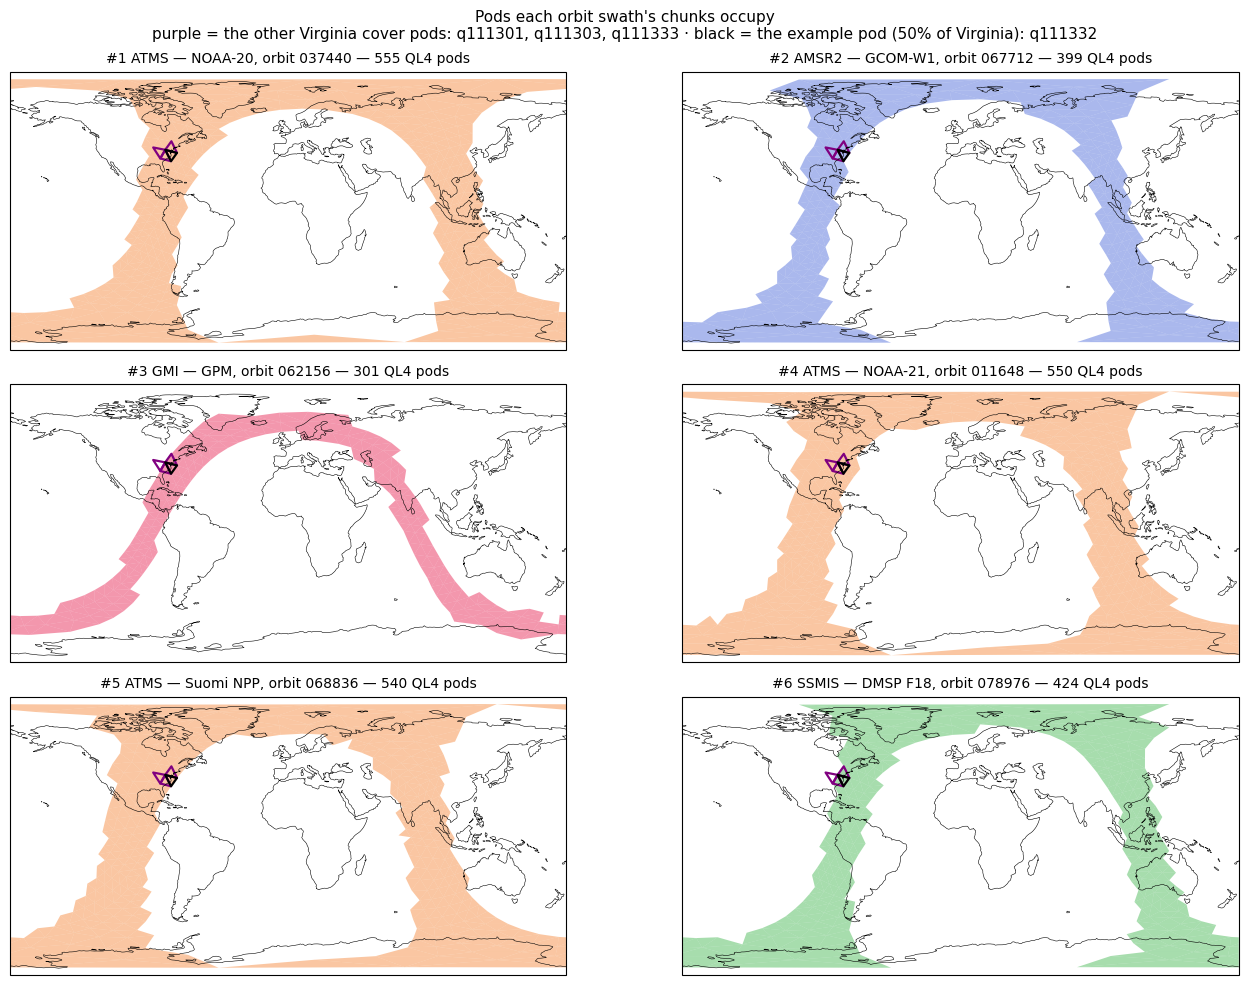

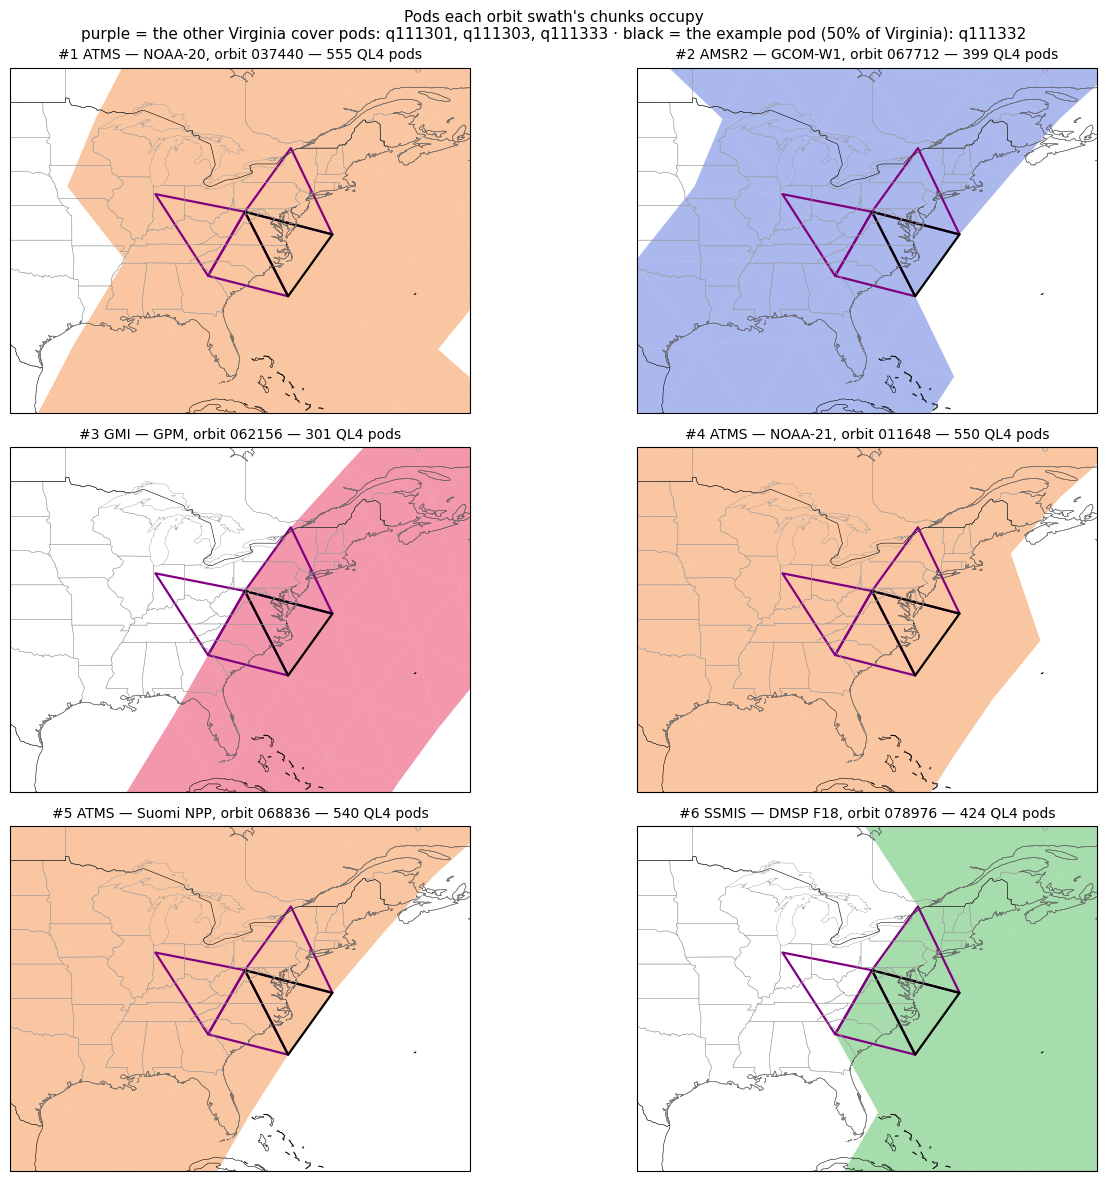

GT(_tbl_data=       kind                                               step   seconds  \
0     local  Virginia's boundary → its QL4 STARE cover; the...  0.148353   
1     query  catalog of the 4 Virginia pods, 2025Q1 — one r...  9.706514   
2     local   find meetings in the Virginia pods at Δt = 5 min  0.026981   
3     local  find meetings in the Virginia pods at Δt = 10 min  0.022268   
4     local  find meetings in the Virginia pods at Δt = 30 min  0.018558   
5     local               rendezvous per pod × window (pandas)  0.013323   
6   display                           render the per-pod table  0.010855   
7     local  pick the example: the first 3-way at the tight...  0.000917   
8     query  full metadata of every chunk, all pods, within...  2.288759   
9     local  each satellite's pass over the example pod nea...  0.178710   
10  display                             render the swath table  0.008913   
11    local  catalog rows of the six swaths, every pod they...  0.007069   
12     plot  build figure 1 — the six orbit swaths around t...  2.549595   
13  display                                    render figure 1  0.270973   
14     plot  build figure 2 — the same six swaths zoomed in...  2.507698   
15  display                                    render figure 2  0.631046   

       share  
0   0.008067  
1   0.527800  
2   0.001467  
3   0.001211  
4   0.001009  
5   0.000724  
6   0.000590  
7   0.000050  
8   0.124453  
9   0.009718  
10  0.000485  
11  0.000384  
12  0.138636  
13  0.014734  
14  0.136358  
15  0.034314  , _body=<great_tables._gt_data.Body object at 0x3925f5e80>, _boxhead=Boxhead([ColInfo(var='kind', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='step', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='seconds', type=<ColInfoTypeEnum.default: 1>, column_label='Seconds', column_align='right', column_width=None), ColInfo(var='share', type=<ColInfoTypeEnum.default: 1>, column_label='Share', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3925e01a0>, _spanners=Spanners([]), _heading=Heading(title='Processing Time of Each Step in this Part 3 Cell', subtitle='18.4 s over 16 steps, in the order they ran', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3925f6d20>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x39250d820>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x3927bbb30>, _formats=[<great_tables._gt_data.FormatInfo object at 0x3925ecf50>, <great_tables._gt_data.FormatInfo object at 0x39260bb30>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values',

⏱  cell [5] took 18.41s


In [5]:
T = StepTimer()
import numpy as np
import pystare
import cartopy.io.shapereader as shpreader
import geopandas
from starepandas.tools.spatial_conversions import sids_from_multipolygon

DC = {'lat': 38.9, 'lon': -77.04}                       # Washington, DC
LOAD_SPAN = pd.Timedelta(hours=3)                       # catalog span loaded around the rendezvous (holds every nearby swath whole)

with T.step('local', 'Virginia\'s boundary → its QL4 STARE cover; the pod over Washington, DC'):
    states = geopandas.read_file(shpreader.natural_earth(
        resolution='50m', category='cultural', name='admin_1_states_provinces_lakes'))
    virginia = states.loc[states['name'] == 'Virginia', 'geometry'].iloc[0]
    va_sids = sorted({int(s) for s in sids_from_multipolygon(virginia, STARE_LEVEL, force_ccw=True)})
    va_pods = sorted({sid_to_podcode(s) for s in va_sids})
    dc_pod = sid_to_podcode(int(pystare.from_latlon(
        np.array([DC['lat']]), np.array([DC['lon']]), STARE_LEVEL)[0]))
    assert dc_pod in va_pods
    # the share of Virginia's area inside each cover pod; the example follows the largest
    overlap = pd.Series({p: g.intersection(virginia).area / virginia.area
                         for p, g in zip(va_pods, pod_trixels(va_pods))})
    focus_pod = overlap.idxmax()
with T.step('query', f'catalog of the {len(va_pods)} Virginia pods, 2025Q1 — one read per pod code'):
    va_catalog = pd.concat([load_s3_temporal_catalog(podcode_prefix=p) for p in va_pods],
                           ignore_index=True)

va_events = {}
for dt in WINDOWS:
    with T.step('local', f'find meetings in the Virginia pods at Δt = {minutes_of(dt)} min'):
        ev = rendezvous_events(va_catalog, dt)
        ev['n'] = ev['instruments'].map(len)
        va_events[dt] = ev

with T.step('local', 'rendezvous per pod × window (pandas)'):
    per_pod = pd.DataFrame({'pod': va_pods})
    per_pod['where'] = per_pod['pod'].map(locate)
    per_pod.loc[per_pod['pod'] == dc_pod, 'where'] = 'Washington, DC; centre ' + per_pod['where']
    per_pod['virginia'] = per_pod['pod'].map(overlap)
    per_pod['chunks'] = per_pod['pod'].map(va_catalog.groupby('podcode').size())
    way_cols = {}
    for dt in WINDOWS:
        counts = va_events[dt].groupby(['podcode', 'n']).size().unstack(fill_value=0)
        for n in (2, 3, 4):
            col = f'{minutes_of(dt)}min_{n}way'
            per_pod[col] = (per_pod['pod'].map(counts[n]).fillna(0).astype(int)
                            if n in counts.columns else 0)
            way_cols.setdefault(dt, []).append(col)
with T.step('display', 'render the per-pod table'):
    table = (GT(per_pod)
             .tab_header(title="Rendezvous in Virginia's QL4 Pods, 2025Q1",
                         subtitle=html(f"<b>{len(va_catalog):,} chunks in {len(va_pods)} pods</b> — "
                                       "rendezvous events at each window, by how many instruments were present"))
             .fmt_integer(columns='chunks')
             .fmt_percent(columns='virginia', decimals=0)
             .cols_label(**{col: f'{n}-way' for cols in way_cols.values()
                            for col, n in zip(cols, (2, 3, 4))},
                         pod="Pod", where="Where", virginia="Share of Virginia"))
    for dt, cols in way_cols.items():
        table = table.tab_spanner(label=f"Δt = {minutes_of(dt)} min", columns=cols)
    display(table.tab_source_note("no 4-way rendezvous over Virginia in three months, at any window; "
                                  "Where = the centre of the pod's trixel; Share of Virginia = the "
                                  "fraction of the state's area inside the pod"))

with T.step('local', 'pick the example: the first 3-way at the tightest window in the pod covering most of Virginia'):
    for EXAMPLE_DT in WINDOWS:
        f3 = va_events[EXAMPLE_DT]
        f3 = f3[(f3['podcode'] == focus_pod) & (f3['n'] >= 3)].sort_values('time')
        if not f3.empty:
            break
    example = f3.iloc[0]
    meeting = example['time']                            # the arrival that completes it
    span = (meeting - LOAD_SPAN, meeting + LOAD_SPAN)
with T.step('query', f'full metadata of every chunk, all pods, within {LOAD_SPAN.components.hours} h of the rendezvous'):
    span_meta = load_s3_metadata(period=span)
with T.step('local', "each satellite's pass over the example pod nearest the rendezvous; which ones rendezvous"):
    span_meta['granule'] = [parse_chunk_filename(p)[1] for p in span_meta['group_path']]
    span_meta['satellite'] = span_meta['granule'].str.split('.').str[1].map(SWATH_SATELLITES)
    span_meta['instrument'] = span_meta['Dataset'].map(fold_instrument)
    in_pod = span_meta[span_meta['podcode'] == focus_pod].reset_index(drop=True)
    # replay the meeting search on the pod's own chunks, asking which passes take part
    pod_events = rendezvous_events(in_pod, EXAMPLE_DT, include_passes=True)
    hit = pod_events[pod_events['time'] == meeting].iloc[0]
    members = set(in_pod.loc[list(hit['passes']), 'granule'])
    swaths = (in_pod.groupby('granule')
              .agg(instrument=('instrument', 'first'), satellite=('satellite', 'first'),
                   pass_start=('t_start', 'min'), pass_end=('t_end', 'max'),
                   chunks=('podcode', 'size'))
              .reset_index())
    swaths['minutes'] = ((swaths['pass_start'] - meeting).dt.total_seconds() / 60).round(1)
    # one swath per satellite: the pass nearest the rendezvous
    swaths = (swaths.iloc[swaths['minutes'].abs().argsort()].drop_duplicates('satellite')
              .sort_values('pass_start').reset_index(drop=True))
    in_pod = in_pod[in_pod['granule'].isin(swaths['granule'])]
    swaths['orbit'] = swaths['granule'].str.split('.').str[5]
    swaths['sensing'] = swaths['granule'].str.split('.').str[4].str.replace(
        r'\d{8}-S(\d{2})(\d{2})\d{2}-E(\d{2})(\d{2})\d{2}', r'\1:\2–\3:\4', regex=True)
    swaths['member'] = swaths['granule'].isin(members).map({True: '✓', False: ''})
    swaths.insert(0, 'order', range(1, len(swaths) + 1))
with T.step('display', 'render the swath table'):
    display(
        GT(fmt_times(swaths, ('pass_start', 'pass_end'))
           [['order', 'instrument', 'satellite', 'orbit', 'sensing', 'pass_start', 'pass_end',
             'chunks', 'minutes', 'member']])
        .tab_header(title=f"Orbit Swaths over Pod {focus_pod} around the Example Rendezvous",
                    subtitle=html(f"<b>{len(swaths)} satellites, each one's pass nearest "
                                  f"{meeting.strftime('%Y-%m-%d %H:%M:%S')} UTC</b> — "
                                  f"the {example['n']} marked ✓ rendezvous within "
                                  f"Δt = {minutes_of(EXAMPLE_DT)} min"))
        .cols_label(order="#", orbit="Orbit", sensing="Granule sensing span (UTC)",
                    pass_start="Start", pass_end="End", chunks="Chunks in the pod",
                    minutes="Minutes from the rendezvous", member=f"In the {minutes_of(EXAMPLE_DT)}-min rendezvous")
        .tab_spanner(label="Pass over the pod", columns=['pass_start', 'pass_end'])
        .tab_source_note("a swath = one granule of one satellite crossing the pod; "
                         "pass = the span of its scan times inside the pod; "
                         "minutes are negative for passes that began before the rendezvous completed; "
                         f"candidates = every pass within {LOAD_SPAN.components.hours} h of the rendezvous")
    )

with T.step('local', 'catalog rows of the six swaths, every pod they touch, labelled per swath'):
    swath_name = {g: f"#{k} {i} — {s}, orbit {o}"
                  for k, g, i, s, o in zip(swaths['order'], swaths['granule'], swaths['instrument'],
                                           swaths['satellite'], swaths['orbit'])}
    swath_catalog = span_meta[span_meta['granule'].isin(swaths['granule'])].copy()
    swath_catalog['swath'] = swath_catalog['granule'].map(swath_name)
    swath_catalog['order'] = swath_catalog['granule'].map(dict(zip(swaths['granule'], swaths['order'])))
    swath_catalog = swath_catalog.sort_values('order')            # panels numbered as the table's rows
    outlines = [([p for p in va_pods if p != focus_pod], 'purple', 'the other Virginia cover pods'),
                ([focus_pod], 'black', f'the example pod ({overlap[focus_pod]:.0%} of Virginia)')]  # drawn last, on top
with T.step('plot', 'build figure 1 — the six orbit swaths around the globe, one panel each'):
    fig = plot_pod_coverage(swath_catalog, group_by='swath', highlight=outlines, figsize=(14, 10))
with T.step('display', 'render figure 1'):
    display(fig)
    plt.close(fig)
with T.step('plot', 'build figure 2 — the same six swaths zoomed in on the eastern United States'):
    fig = plot_pod_coverage(swath_catalog, group_by='swath', highlight=outlines,
                            extent=(-100, -60, 22, 52), figsize=(14, 12))
with T.step('display', 'render figure 2'):
    display(fig)
    plt.close(fig)
display(T.table("Processing Time of Each Step in this Part 3 Cell"))


## Part 4 — Rendezvous up close

Two views of the example pod, at the data-element level. A rendezvous must satisfy
**both** criteria — same pod *and* same time window — so each figure shows
both: on the left, the data-element locations inside the pod's trixel, with
Virginia's outline dashed (the pod holds about half the state) and
Washington D.C. circled; on the right, each pass on the time axis. The figures draw each swath's **first
scan group only** (`GMI_S1`, `ATMS_S1`, …) so that one swath is one set of
scan lines; the tables list the other scan groups' counts beside it.

First all six orbit swaths of Part 3 in the same pod, just over two hours
end to end — one pass per satellite, with what each left in the pod. Then
the rendezvous itself: the three that meet within **Δt = 5 minutes** —
AMSR2, then GMI, then ATMS on NOAA-21. The other three cross the same
ground, but between 25 and 75 minutes away from the rendezvous, so no 5-,
10- or 30-minute window can join them to it. Note, on the time axis, the
two ATMS swaths that are *not* in the rendezvous — NOAA-20 and Suomi NPP,
the same instrument on
other satellites, following the same ground track roughly 50 minutes
before and 25 minutes after NOAA-21.

Rendezvous here is performed at the **pod level** — a fast but broad way to
find overlaps between instruments' coverages. Once found, the STARE hierarchy
can be leveraged again to refine them to exact **data-element-level**
overlaps.


GT(_tbl_data=                 swath  data elements  \
0    ATMS_S1 (NOAA-20)            773   
1   AMSR2_S1 (GCOM-W1)           3471   
2         GMI_S1 (GPM)           3096   
3    ATMS_S1 (NOAA-21)            327   
4  ATMS_S1 (Suomi NPP)             37   
5  SSMIS_S1 (DMSP F18)            910   

                                   other scan groups pass start  pass end  \
0                        S2: 775 · S3: 772 · S4: 779   06:44:11  06:46:03   
1  S2: 3,461 · S3: 3,460 · S4: 3,452 · S5: 6,856 ...   07:31:17  07:34:16   
2                                          S2: 3,078   07:34:13  07:36:09   
3                        S2: 325 · S3: 327 · S4: 328   07:36:00  07:37:44   
4                           S2: 37 · S3: 37 · S4: 37   08:01:40  08:02:17   
5                    S2: 911 · S3: 1,798 · S4: 1,802   08:48:02  08:50:11   

  in the rendezvous  
0                    
1                 ✓  
2                 ✓  
3                 ✓  
4                    
5                    , _body=<great_tables._gt_data.Body object at 0x3790c05f0>, _boxhead=Boxhead([ColInfo(var='swath', type=<ColInfoTypeEnum.default: 1>, column_label='Swath', column_align='left', column_width=None), ColInfo(var='data elements', type=<ColInfoTypeEnum.default: 1>, column_label='Data elements', column_align='right', column_width=None), ColInfo(var='other scan groups', type=<ColInfoTypeEnum.default: 1>, column_label='Other scan groups', column_align='left', column_width=None), ColInfo(var='pass start', type=<ColInfoTypeEnum.default: 1>, column_label='Pass start', column_align='right', column_width=None), ColInfo(var='pass end', type=<ColInfoTypeEnum.default: 1>, column_label='Pass end', column_align='right', column_width=None), ColInfo(var='in the rendezvous', type=<ColInfoTypeEnum.default: 1>, column_label='In the rendezvous', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3790c9550>, _spanners=Spanners([]), _heading=Heading(title='Pod q111332 — All 6 Orbit Swaths in the Pod', subtitle='first scan group of each swath, in order of arrival — the six passes nearest the rendezvous, 2025-02-08 06:44 → 08:50 UTC', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3790c8a40>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3790c8fb0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x3790c8890>, _formats=[<great_tables._gt_data.FormatInfo object at 0x3790cad50>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid

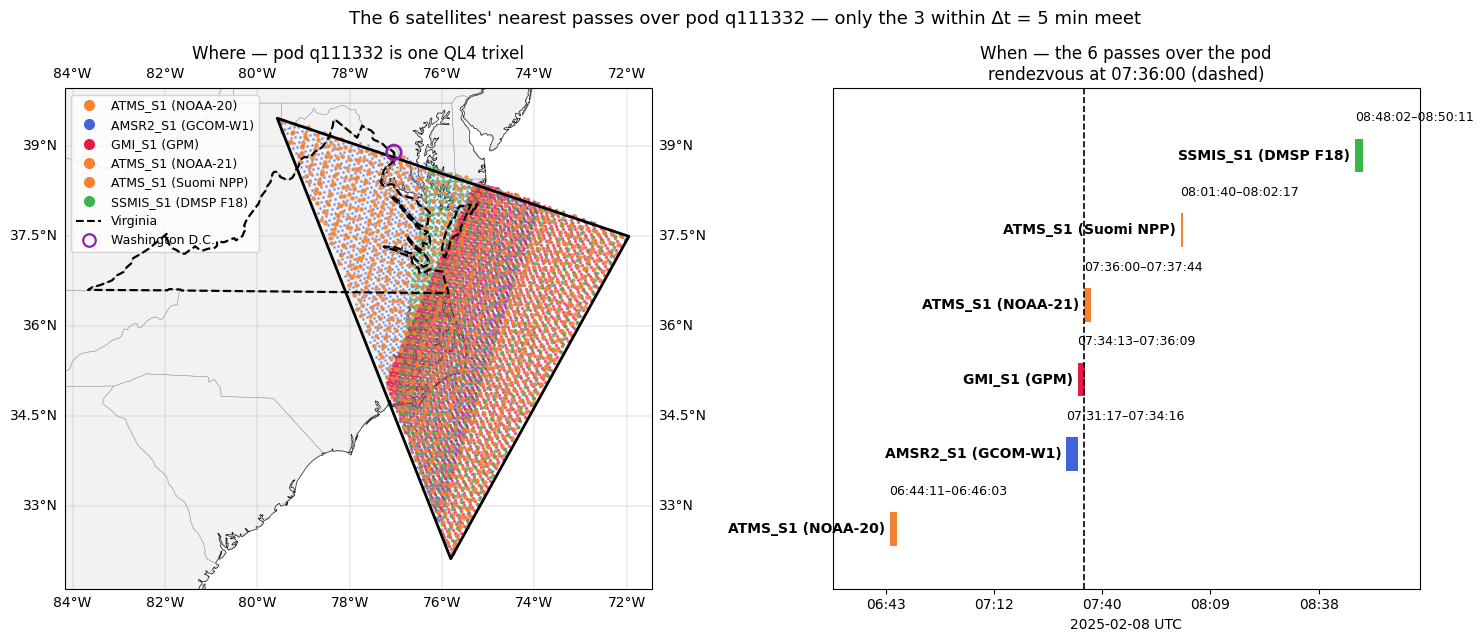

GT(_tbl_data=                swath  data elements  \
0  AMSR2_S1 (GCOM-W1)           3471   
1        GMI_S1 (GPM)           3096   
2   ATMS_S1 (NOAA-21)            327   

                                   other scan groups pass start  pass end  \
0  S2: 3,461 · S3: 3,460 · S4: 3,452 · S5: 6,856 ...   07:31:17  07:34:16   
1                                          S2: 3,078   07:34:13  07:36:09   
2                        S2: 325 · S3: 327 · S4: 328   07:36:00  07:37:44   

  in the rendezvous  
0                 ✓  
1                 ✓  
2                 ✓  , _body=<great_tables._gt_data.Body object at 0x3790c8350>, _boxhead=Boxhead([ColInfo(var='swath', type=<ColInfoTypeEnum.default: 1>, column_label='Swath', column_align='left', column_width=None), ColInfo(var='data elements', type=<ColInfoTypeEnum.default: 1>, column_label='Data elements', column_align='right', column_width=None), ColInfo(var='other scan groups', type=<ColInfoTypeEnum.default: 1>, column_label='Other scan groups', column_align='left', column_width=None), ColInfo(var='pass start', type=<ColInfoTypeEnum.default: 1>, column_label='Pass start', column_align='right', column_width=None), ColInfo(var='pass end', type=<ColInfoTypeEnum.default: 1>, column_label='Pass end', column_align='right', column_width=None), ColInfo(var='in the rendezvous', type=<ColInfoTypeEnum.default: 1>, column_label='In the rendezvous', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x392923da0>, _spanners=Spanners([]), _heading=Heading(title='Pod q111332 — a 3-Way Rendezvous', subtitle='first scan group of each swath, in order of arrival, all inside Δt = 5 min; the rendezvous completes 2025-02-08 07:36:00', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x392921a90>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x392920cb0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x3927ca810>, _formats=[<great_tables._gt_data.FormatInfo object at 0x3790fe360>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, categ

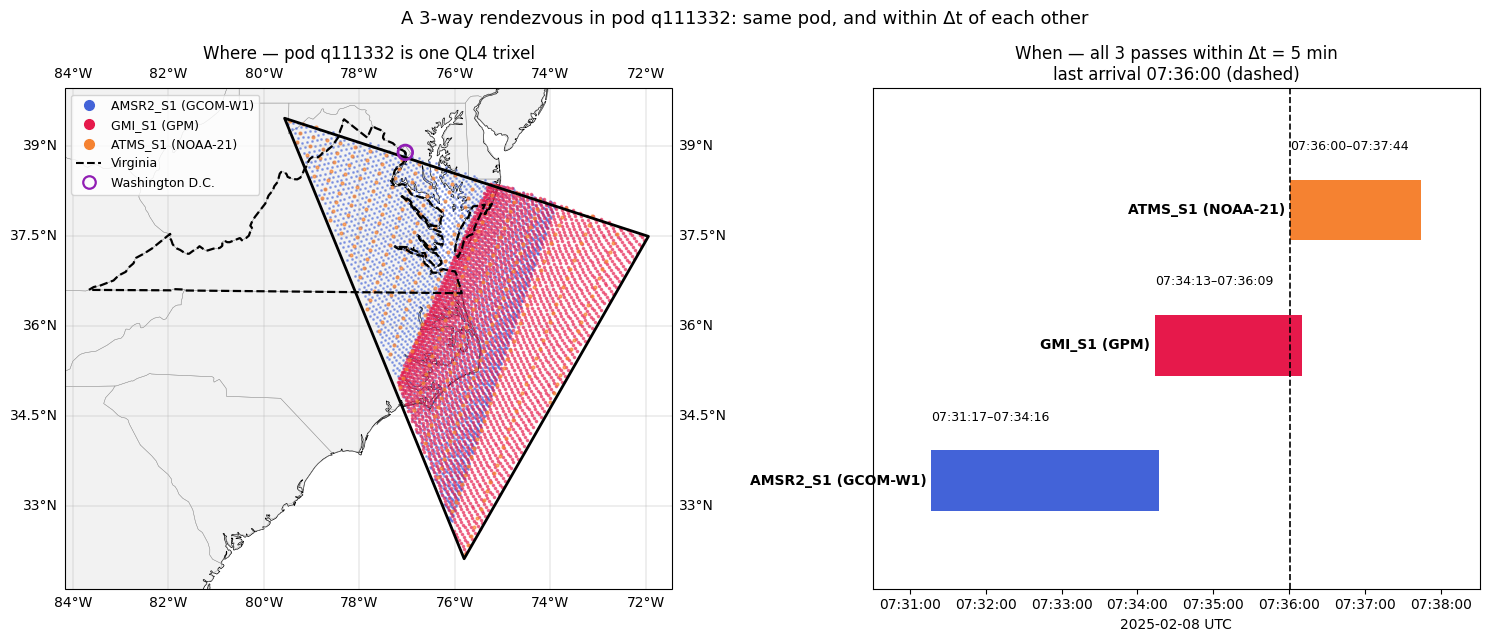

GT(_tbl_data=       kind                                               step   seconds  \
0  download  read the 6 S1 chunks from S3 (Parquet) — all 6...  3.306503   
1   display  render the arrival table — all 6 orbit swaths ...  0.019147   
2      plot     build figure 3 — all 6 orbit swaths in the pod  0.088763   
3   display                                    render figure 3  1.634888   
4  download  read the 3 S1 chunks from S3 (Parquet) — the 3...  1.399672   
5   display  render the arrival table — the 3 swaths of the...  0.016334   
6      plot    build figure 4 — the 3 swaths of the rendezvous  0.067899   
7   display                                    render figure 4  0.154563   

      share  
0  0.494410  
1  0.002863  
2  0.013272  
3  0.244459  
4  0.209288  
5  0.002442  
6  0.010153  
7  0.023111  , _body=<great_tables._gt_data.Body object at 0x392575cd0>, _boxhead=Boxhead([ColInfo(var='kind', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='step', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='seconds', type=<ColInfoTypeEnum.default: 1>, column_label='Seconds', column_align='right', column_width=None), ColInfo(var='share', type=<ColInfoTypeEnum.default: 1>, column_label='Share', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3928d7620>, _spanners=Spanners([]), _heading=Heading(title='Processing Time of Each Step in this Part 4 Cell', subtitle='6.7 s over 8 steps, in the order they ran', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3790c2870>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3928798e0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x3928dd2b0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x3928a40b0>, <great_tables._gt_data.FormatInfo object at 0x3792f2270>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsIn

⏱  cell [6] took 6.71s


In [6]:
T = StepTimer()
from starepandas.demo_plots import swath_label
pod_s1 = in_pod[in_pod['Dataset'].str.endswith('_S1')]             # first scan group of the six swaths
granule_of = {swath_label(d, g): g for d, g in zip(pod_s1['Dataset'], pod_s1['granule'])}
assert len(granule_of) == pod_s1['granule'].nunique()               # one label per swath
other_groups = (in_pod[~in_pod['Dataset'].str.endswith('_S1')]
                .groupby('granule').apply(lambda g: ' · '.join(
                    f"{d.split('_', 1)[1]}: {n:,}" for d, n in
                    g.groupby('Dataset')['num_rows'].sum().items()), include_groups=False))

cases = [
    (pod_s1,
     f"all {pod_s1['granule'].nunique()} orbit swaths in the pod",
     f"The {pod_s1['granule'].nunique()} satellites' nearest passes over pod {focus_pod} — "
     f"only the {len(members)} within Δt = {minutes_of(EXAMPLE_DT)} min meet"),
    (pod_s1[pod_s1['granule'].isin(members)],
     f"the {len(members)} swaths of the rendezvous", None),
]
for k, (rows, what, title) in enumerate(cases, start=3):
    with T.step('download', f'read the {len(rows)} S1 chunks from S3 (Parquet) — {what}'):
        passes = swath_pixels(demo, rows, span)             # one entry per orbit swath
    arrival = pd.DataFrame([
        {'swath': label,
         'data elements': len(px),
         'other scan groups': other_groups.get(granule_of[label], ''),
         'pass start': px['timestamp'].min().strftime('%H:%M:%S'),
         'pass end': px['timestamp'].max().strftime('%H:%M:%S'),
         'in the rendezvous': '✓' if granule_of[label] in members else ''}
        for label, px in passes.items()
    ])
    first_pass = min(px['timestamp'].min() for px in passes.values())
    last_pass = max(px['timestamp'].max() for px in passes.values())
    with T.step('display', f'render the arrival table — {what}'):
        display(
            GT(arrival)
            .tab_header(title=(f"Pod {focus_pod} — a {len(passes)}-Way Rendezvous" if title is None
                               else f"Pod {focus_pod} — All {len(passes)} Orbit Swaths in the Pod"),
                        subtitle=("first scan group of each swath, in order of arrival, "
                                  f"all inside Δt = {minutes_of(EXAMPLE_DT)} min; the rendezvous completes "
                                  f"{meeting.strftime('%Y-%m-%d %H:%M:%S')}" if title is None else
                                  "first scan group of each swath, in order of arrival — the six passes "
                                  f"nearest the rendezvous, {first_pass.strftime('%Y-%m-%d %H:%M')} → "
                                  f"{last_pass.strftime('%H:%M')} UTC"))
            .fmt_integer(columns='data elements')
        )
    with T.step('plot', f'build figure {k} — {what}'):
        fig = plot_rendezvous(focus_pod, passes, meeting, EXAMPLE_DT, title=title,
                              region=virginia, region_label='Virginia',
                              point=(DC['lon'], DC['lat']), point_label='Washington D.C.')
    with T.step('display', f'render figure {k}'):
        display(fig)
        plt.close(fig)
display(T.table("Processing Time of Each Step in this Part 4 Cell"))


## Part 5 — Rendezvous over a region of interest

The real-world question: *what did every instrument see over **Virginia**
during these six hours?* — a spatial criterion, the state's boundary, and a
temporal one, the six hours around Part 3's rendezvous. STARE turns the
boundary into a cover of four QL4 trixels (STARE's adaptive resolution at
work), the database answers the spatial and the temporal criteria, and the
AND of the two is the result — a small set of chunks that can be read
straight from S3, with no scan through the swaths that never crossed the
state or crossed it at another hour.

The message is in the counts: space alone picks every pass of every
instrument over Virginia for three months, time alone picks every chunk on
Earth in those six hours, and the two together leave 128 chunks of eleven
orbit swaths. Two figures: the region itself — Virginia, the
cover it becomes, every cover pod holding data — and the result: the data
elements the query returns (whole chunks, pod-level granularity, so they
extend past the state line) beside each spatially-selected chunk's time span
on the query day. The tables are the full answer, every scan group; the
figures draw each instrument's **first scan group** only.


GT(_tbl_data=           criterion                                              value
0   Region (spatial)  the state of Virginia → 4 QL4 cover trixels → ...
1  Period (temporal)  2025-02-08 04:36:00 → 10:36:00 UTC — the Part ..., _body=<great_tables._gt_data.Body object at 0x3928df440>, _boxhead=Boxhead([ColInfo(var='criterion', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='value', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3928dde80>, _spanners=Spanners([]), _heading=Heading(title='The Region-of-Interest Query', subtitle='a spatial criterion AND a temporal criterion', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3792f3e90>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3792f01a0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x3792f1730>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, ca

GT(_tbl_data=                                           criterion  chunks
0  Temporal only — everything in the six hours, a...   38574
1   Spatial only — Virginia, any time in the quarter   20216
2             Spatial only — Virginia, the query day     252
3     Spatial AND temporal — Virginia, the six hours     128, _body=<great_tables._gt_data.Body object at 0x3b290c770>, _boxhead=Boxhead([ColInfo(var='criterion', type=<ColInfoTypeEnum.default: 1>, column_label='Criterion', column_align='left', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label='Chunks', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3b290eb70>, _spanners=Spanners([]), _heading=Heading(title='One Query, Both Criteria — the Whole Store', subtitle=Html(text='<b>128 chunks of 11 orbit swaths match both criteria</b>, in 4 of the 4 cover pods'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3b290e0f0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3b290e270>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x3b290e330>, _formats=[<great_tables._gt_data.FormatInfo object at 0x3b290d3a0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bo

GT(_tbl_data=  instrument  satellite  swaths  chunks          first_start  \
0      AMSR2    GCOM-W1       1      24  2025-02-08 07:29:45   
1       ATMS    NOAA-20       2      20  2025-02-08 06:42:32   
2       ATMS    NOAA-21       2      28  2025-02-08 05:54:00   
3       ATMS  Suomi NPP       2      32  2025-02-08 06:19:40   
4        GMI        GPM       2       8  2025-02-08 07:33:34   
5      SSMIS   DMSP F18       2      16  2025-02-08 08:47:22   

              last_end  
0  2025-02-08 07:34:24  
1  2025-02-08 08:25:23  
2  2025-02-08 07:37:44  
3  2025-02-08 08:03:21  
4  2025-02-08 09:11:07  
5  2025-02-08 10:31:13  , _body=<great_tables._gt_data.Body object at 0x3b290cec0>, _boxhead=Boxhead([ColInfo(var='instrument', type=<ColInfoTypeEnum.default: 1>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='satellite', type=<ColInfoTypeEnum.default: 1>, column_label='Satellite', column_align='left', column_width=None), ColInfo(var='swaths', type=<ColInfoTypeEnum.default: 1>, column_label='Swaths', column_align='right', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label='Both criteria', column_align='right', column_width=None), ColInfo(var='first_start', type=<ColInfoTypeEnum.default: 1>, column_label='First t_start', column_align='right', column_width=None), ColInfo(var='last_end', type=<ColInfoTypeEnum.default: 1>, column_label='Last t_end', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3b290dca0>, _spanners=Spanners([]), _heading=Heading(title='Chunks Matching Both Criteria, by Instrument and Satellite', subtitle='11 orbit swaths crossed Virginia in the six hours', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3b290dd90>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3b290d010>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x3b290d760>, _formats=[<great_tables._gt_data.FormatInfo object at 0x3b290dac0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='ta

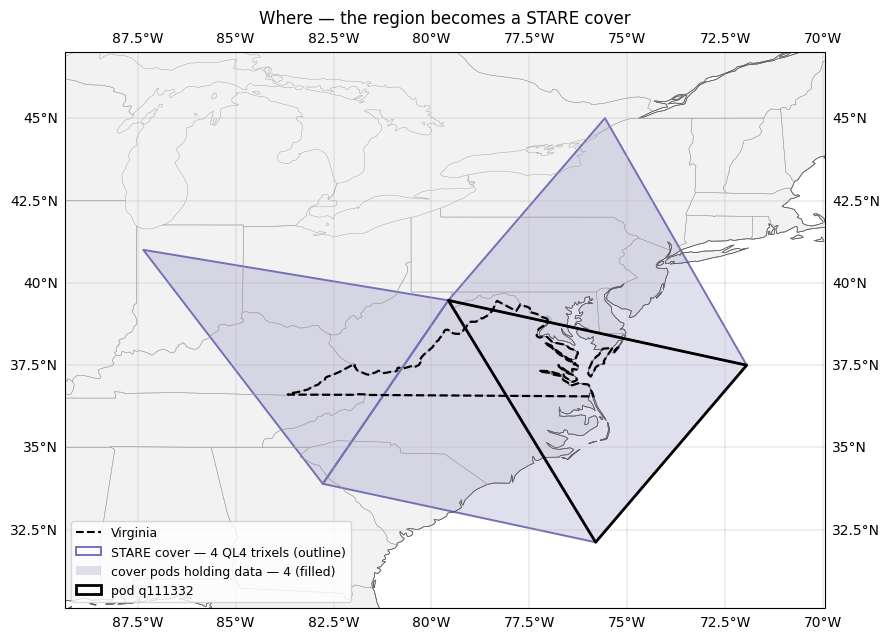

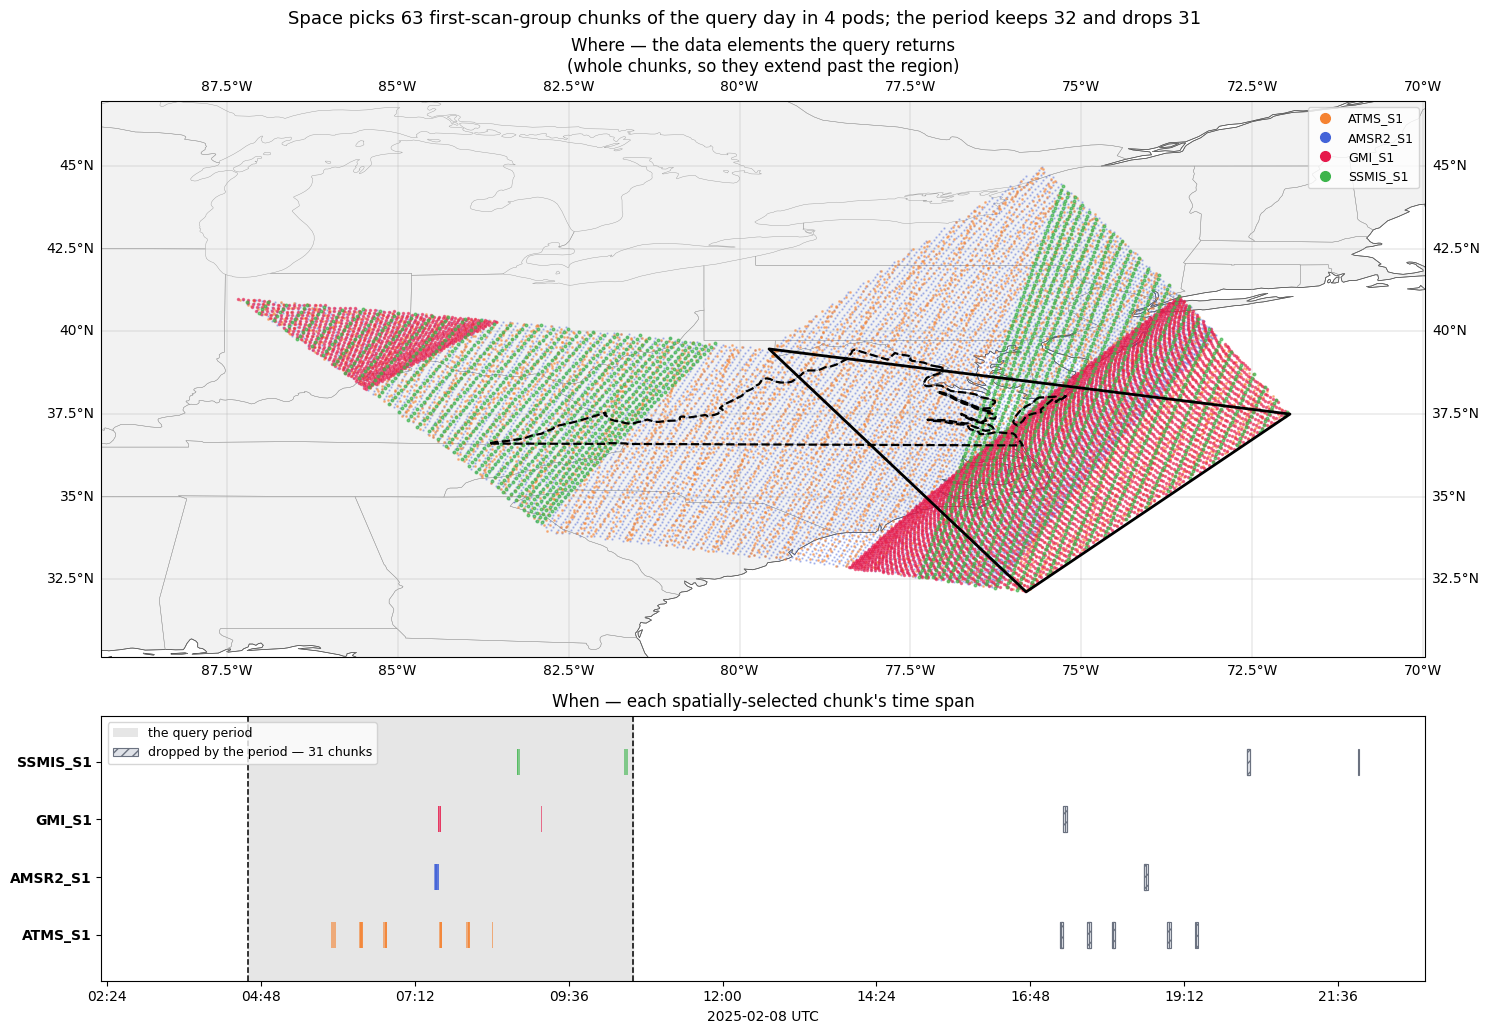

GT(_tbl_data=        kind                                               step    seconds  \
0    display                             render the query table   0.004003   
1      query  spatial only, whole quarter — 4 pod-code catal...   9.285614   
2      local  restrict the spatial pick to the query day (fo...   0.001326   
3      query  temporal only — the whole catalog inside the w...   1.875681   
4      query  spatial AND temporal — the region query, whole...   9.535475   
5    display                          render the criteria table   0.004545   
6      local  chunks matching both criteria, per instrument ...   0.003708   
7    display                     render the per-satellite table   0.006719   
8       plot  build figure 5 — Virginia and its STARE cover,...   0.049354   
9    display                                    render figure 5   0.365042   
10     local  keep the first scan group of each instrument f...   0.001380   
11  download   read the 32 matching S1 chunks from S3 (Parquet)  16.144982   
12      plot  build figure 6 — S1 data elements + the query ...   0.092965   
13   display                                    render figure 6   0.196380   

       share  
0   0.000107  
1   0.247174  
2   0.000035  
3   0.049929  
4   0.253825  
5   0.000121  
6   0.000099  
7   0.000179  
8   0.001314  
9   0.009717  
10  0.000037  
11  0.429763  
12  0.002475  
13  0.005227  , _body=<great_tables._gt_data.Body object at 0x3adc41a90>, _boxhead=Boxhead([ColInfo(var='kind', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='step', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='seconds', type=<ColInfoTypeEnum.default: 1>, column_label='Seconds', column_align='right', column_width=None), ColInfo(var='share', type=<ColInfoTypeEnum.default: 1>, column_label='Share', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3ae5f3740>, _spanners=Spanners([]), _heading=Heading(title='Processing Time of Each Step in this Part 5 Cell', subtitle='37.6 s over 14 steps, in the order they ran', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3adc39130>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3adc39910>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x3adc398e0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x3adc3b080>, <great_tables._gt_data.FormatInfo object at 0x3ae635f40>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto'

⏱  cell [7] took 37.58s


In [7]:
T = StepTimer()
REGION_DT = pd.Timedelta(hours=3)                        # ± around the rendezvous: a six-hour window
window = (meeting - REGION_DT, meeting + REGION_DT)
query = pd.DataFrame([
    {'criterion': 'Region (spatial)',
     'value': f"the state of Virginia → {len(va_sids)} QL{STARE_LEVEL} cover trixels "
              f"→ pods {', '.join(va_pods)}"},
    {'criterion': 'Period (temporal)',
     'value': f"{window[0].strftime('%Y-%m-%d %H:%M:%S')} → {window[1].strftime('%H:%M:%S')} UTC "
              f"— the Part 3 rendezvous ± {REGION_DT.components.hours} h"},
])
with T.step('display', 'render the query table'):
    display(
        GT(query)
        .tab_header(title="The Region-of-Interest Query",
                    subtitle="a spatial criterion AND a temporal criterion")
        .cols_label(criterion="", value="")
    )

with T.step('query', f'spatial only, whole quarter — {len(va_pods)} pod-code catalog reads'):
    spatial_q = pd.concat([load_s3_temporal_catalog(podcode_prefix=p) for p in va_pods],
                          ignore_index=True)
with T.step('local', 'restrict the spatial pick to the query day (for the timeline)'):
    day = (window[0].normalize(), window[0].normalize() + pd.Timedelta(days=1))
    spatial_day = spatial_q[(spatial_q['t_start'] <= day[1]) & (spatial_q['t_end'] >= day[0])]
with T.step('query', 'temporal only — the whole catalog inside the window'):
    temporal_q = load_s3_metadata(period=window)
with T.step('query', 'spatial AND temporal — the region query, whole catalog'):
    both_q = demo.find_intersecting_data(va_sids, INSTRUMENTS, period=window)
    both_q['granule'] = [parse_chunk_filename(p)[1] for p in both_q['group_path']]
    both_q['instrument'] = both_q['Dataset'].map(fold_instrument)
    both_q['satellite'] = both_q['granule'].str.split('.').str[1].map(SWATH_SATELLITES)

criteria_q = pd.DataFrame([
    {'criterion': 'Temporal only — everything in the six hours, anywhere on Earth',
     'chunks': len(temporal_q)},
    {'criterion': 'Spatial only — Virginia, any time in the quarter', 'chunks': len(spatial_q)},
    {'criterion': 'Spatial only — Virginia, the query day', 'chunks': len(spatial_day)},
    {'criterion': 'Spatial AND temporal — Virginia, the six hours', 'chunks': len(both_q)},
])
with T.step('display', 'render the criteria table'):
    display(
        GT(criteria_q)
        .tab_header(title="One Query, Both Criteria — the Whole Store",
                    subtitle=html(f"<b>{len(both_q):,} chunks of {both_q['granule'].nunique()} orbit swaths "
                                  f"match both criteria</b>, in {both_q['podcode'].nunique()} of the "
                                  f"{len(va_pods)} cover pods"))
        .fmt_integer(columns='chunks')
    )

with T.step('local', 'chunks matching both criteria, per instrument and satellite (pandas)'):
    per_sat = (both_q.groupby(['instrument', 'satellite'])
               .agg(swaths=('granule', 'nunique'), chunks=('podcode', 'size'),
                    first_start=('t_start', 'min'), last_end=('t_end', 'max'))
               .reset_index())
with T.step('display', 'render the per-satellite table'):
    display(
        GT(fmt_times(per_sat, ('first_start', 'last_end')))
        .tab_header(title="Chunks Matching Both Criteria, by Instrument and Satellite",
                    subtitle=f"{per_sat['swaths'].sum()} orbit swaths crossed Virginia in the six hours")
        .fmt_integer(columns='chunks')
        .cols_label(swaths="Swaths", chunks="Both criteria",
                    first_start="First t_start", last_end="Last t_end")
    )

with T.step('plot', 'build figure 5 — Virginia and its STARE cover, every cover pod holding data'):
    fig = plot_region_cover(None, va_sids, spatial_q, highlight_pod=focus_pod,
                            region=virginia, region_label='Virginia')
with T.step('display', 'render figure 5'):
    display(fig)
    plt.close(fig)
with T.step('local', 'keep the first scan group of each instrument for the figure'):
    both_q_s1 = both_q[both_q['Dataset'].str.endswith('_S1')]
    spatial_day_s1 = spatial_day[spatial_day['Dataset'].str.endswith('_S1')]
with T.step('download', f'read the {len(both_q_s1)} matching S1 chunks from S3 (Parquet)'):
    region_passes_q = chunk_pixels(demo, both_q_s1, window, fold=False)
with T.step('plot', 'build figure 6 — S1 data elements + the query day\'s S1 chunk timeline'):
    fig = plot_region_result(region_passes_q, spatial_day_s1, window, bbox=None,
                             region=virginia, highlight_pod=focus_pod, fold=False,
                             subject='first-scan-group chunks of the query day')
with T.step('display', 'render figure 6'):
    display(fig)
    plt.close(fig)
display(T.table("Processing Time of Each Step in this Part 5 Cell"))


## Part 6 — Performance at scale

Part 2 covered the whole quarter in one go; Parts 3–5 asked for one corner
of it. What does the engine cost as the scope grows? Part 2's pipeline is repeated
on the bulk-store root — 7,344 granules, 12.4 million chunks; the store also
holds two small test roots, 16 granules and 21,404 chunks, which Part 2
counted and Part 6 leaves out — at four scopes — a day, a week, a
month, the quarter — timing each stage: the **catalog read** (four columns per
chunk — pod code, scan group, `t_start`, `t_end` — and nothing else leaves the
database), the **meeting search** (`rendezvous_events`: one run through each pod's
chunks in time order), and the **aggregation** into the pair matrix and the
per-pod table.

Two things to watch. The analytics never open a chunk — S3 is not touched, so
the cost is the catalog's, not the data volume's. And the search is **flat in
n**: the 2-way, 3-way and 4-way counts all fall out of the *same* single
run through the catalog, at the same cost — there is no pairwise join whose cost grows with the
number of instruments.


In [8]:
T = StepTimer()
PART6_DT = WINDOWS[1]                           # 10 min, as Part 2's matrix
PART6_MIN = minutes_of(PART6_DT)
SCOPES = [
    ('one day (Feb 5)',     (pd.Timestamp('2025-02-05'), pd.Timestamp('2025-02-06'))),
    ('one week (Feb 5–11)', (pd.Timestamp('2025-02-05'), pd.Timestamp('2025-02-12'))),
    ('one month (Feb)',     (pd.Timestamp('2025-02-01'), pd.Timestamp('2025-03-01'))),
    ('the quarter',         None),
]
perf_rows = []
for label, period in SCOPES:
    with T.step('query', f'read 4 catalog columns — {label}'):
        scoped = load_s3_temporal_catalog(path_prefix=STORE_PREFIX, period=period)
    t_load = T.last
    with T.step('local', f'find meetings (rendezvous_events) — {label}'):
        ev = rendezvous_events(scoped, PART6_DT)
    t_sweep = T.last
    with T.step('local', f'aggregate (matrix + pod table) — {label}'):
        mat, tab = overlap_matrix(ev), overlap_pod_table(ev)
    t_agg = T.last
    row = {'scope': label, 'chunks': len(scoped), 'load_s': t_load,
           'sweep_s': t_sweep, 'aggregate_s': t_agg, 'events': len(ev)}
    for n in (2, 3, 4):
        row[f'{n}-way'] = int(tab[n].gt(0).sum()) if n in tab.columns else 0
    perf_rows.append(row)
    if period is None:                      # keep the quarter's results
        quarter_events, quarter_matrix, quarter_table = ev, mat, tab
    del scoped
perf = pd.DataFrame(perf_rows)
with T.step('display', 'render the scope × stage table'):
    display(
        GT(perf)
        .tab_header(title=f"The Rendezvous Engine at Scale — Bulk-Store Root, Δt = {PART6_MIN} min",
                    subtitle="the same three stages as Part 2, on a day, a week, a month "
                             "and the whole of 2025Q1; no chunk is ever opened")
        .fmt_integer(columns=['chunks', 'events'])
        .fmt_number(columns=['load_s', 'sweep_s', 'aggregate_s'], decimals=1)
        .tab_spanner(label="seconds", columns=['load_s', 'sweep_s', 'aggregate_s'])
        .tab_spanner(label="QL4 Pods with an n-way Rendezvous",
                     columns=['2-way', '3-way', '4-way'])
        .cols_label(scope="", load_s="Read catalog", sweep_s="Find meetings", aggregate_s="Aggregate")
    )

with T.step('local', 'split the quarter\'s events by n-way (pandas)'):
    quarter_sweep_s = perf.loc[perf['scope'] == 'the quarter', 'sweep_s'].iloc[0]
    widths = quarter_events['instruments'].map(len)
    flat = pd.DataFrame([
        {'width': f'{n}-way',
         'pods': int(quarter_table[n].gt(0).sum()),
         'events': int((widths == n).sum())}
        for n in (2, 3, 4)
    ])   # an event = one pass arriving at a pod while others are still active
with T.step('display', 'render the flat-in-n table'):
    display(
        GT(flat)
        .tab_header(title="Flat in n — One Search Answers 2-, 3- and 4-Way at Once",
                    subtitle=f"the quarter's {len(quarter_events):,} events in total, split by n — the three "
                             f"rows add up to it, all from the one {quarter_sweep_s:.1f} s search")
        .fmt_integer(columns='events')
        .cols_label(width="", pods="Pods with an n-way", events="Events at n-way")
        .tab_source_note("an event is one pass arriving at a pod while other "
                         "instruments are still present there; n is how many "
                         "instruments are present at that moment, the arriving "
                         "one included; each event is counted once, at its own n")
    )

with T.step('local', 'shape the quarter matrix'):
    qm = quarter_matrix.astype(object)
    for instrument in qm.index:
        qm.loc[instrument, instrument] = '—'
    qm.insert(0, 'instrument', qm.index)
with T.step('display', 'render the quarter matrix'):
    display(
        GT(qm.reset_index(drop=True), rowname_col='instrument')
        .tab_header(title="Who Met Whom over 2025Q1 — Pods Where Each Pair Rendezvous",
                    subtitle=f"Δt = {PART6_MIN} min; of {8 * 4 ** STARE_LEVEL} QL{STARE_LEVEL} "
                             "pods — identical to Part 2's 10-minute matrix: the two test "
                             "roots add no pairs")
    )
display(T.table("Processing Time of Each Step in this Part 6 Cell"))


GT(_tbl_data=                 scope    chunks     load_s    sweep_s  aggregate_s   events  \
0      one day (Feb 5)    149779   1.728434   0.129868     0.036930    33813   
1  one week (Feb 5–11)   1037410  19.774976   0.897885     0.157361   207927   
2      one month (Feb)   4142972  20.730346   3.997869     0.538865   835684   
3          the quarter  12430463  37.721759  14.060521     1.408373  2335819   

   2-way  3-way  4-way  
0   2017    354      3  
1   2048   1371     13  
2   2048   1747     35  
3   2048   1983     65  , _body=<great_tables._gt_data.Body object at 0x3ae5f6db0>, _boxhead=Boxhead([ColInfo(var='scope', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label='Chunks', column_align='right', column_width=None), ColInfo(var='load_s', type=<ColInfoTypeEnum.default: 1>, column_label='Read catalog', column_align='right', column_width=None), ColInfo(var='sweep_s', type=<ColInfoTypeEnum.default: 1>, column_label='Find meetings', column_align='right', column_width=None), ColInfo(var='aggregate_s', type=<ColInfoTypeEnum.default: 1>, column_label='Aggregate', column_align='right', column_width=None), ColInfo(var='events', type=<ColInfoTypeEnum.default: 1>, column_label='Events', column_align='right', column_width=None), ColInfo(var='2-way', type=<ColInfoTypeEnum.default: 1>, column_label='2-way', column_align='right', column_width=None), ColInfo(var='3-way', type=<ColInfoTypeEnum.default: 1>, column_label='3-way', column_align='right', column_width=None), ColInfo(var='4-way', type=<ColInfoTypeEnum.default: 1>, column_label='4-way', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3405dd7f0>, _spanners=Spanners([SpannerInfo(spanner_id='seconds', spanner_level=0, spanner_label='seconds', spanner_units=None, spanner_pattern=None, vars=['load_s', 'sweep_s', 'aggregate_s'], built=None), SpannerInfo(spanner_id='QL4 Pods with an n-way Rendezvous', spanner_level=0, spanner_label='QL4 Pods with an n-way Rendezvous', spanner_units=None, spanner_pattern=None, vars=['2-way', '3-way', '4-way'], built=None)]), _heading=Heading(title='The Rendezvous Engine at Scale — Bulk-Store Root, Δt = 10 min', subtitle='the same three stages as Part 2, on a day, a week, a month and the whole of 2025Q1; no chunk is ever opened', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3adc6cd70>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3adc6c350>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x3adc6dd00>, _formats=[<great_tables._gt_data.FormatInfo object at 0x3adc6d820>, <great_tables._gt_data.FormatInfo object at 0x3adc6d760>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'

GT(_tbl_data=   width  pods   events
0  2-way  2048  2102716
1  3-way  1983   232528
2  4-way    65      575, _body=<great_tables._gt_data.Body object at 0x3adc6fcb0>, _boxhead=Boxhead([ColInfo(var='width', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='pods', type=<ColInfoTypeEnum.default: 1>, column_label='Pods with an n-way', column_align='right', column_width=None), ColInfo(var='events', type=<ColInfoTypeEnum.default: 1>, column_label='Events at n-way', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3adc2e690>, _spanners=Spanners([]), _heading=Heading(title='Flat in n — One Search Answers 2-, 3- and 4-Way at Once', subtitle="the quarter's 2,335,819 events in total, split by n — the three rows add up to it, all from the one 14.1 s search", preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3ae470530>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3ae471490>, _source_notes=['an event is one pass arriving at a pod while other instruments are still present there; n is how many instruments are present at that moment, the arriving one included; each event is counted once, at its own n'], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x3ae473800>, _formats=[<great_tables._gt_data.FormatInfo object at 0x3adc6f770>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, c

GT(_tbl_data=  instrument AMSR2  ATMS   GMI SSMIS
0      AMSR2     —  2048  1976   473
1       ATMS  2048     —  1980   653
2        GMI  1976  1980     —  1963
3      SSMIS   473   653  1963     —, _body=<great_tables._gt_data.Body object at 0x3adc6fcb0>, _boxhead=Boxhead([ColInfo(var='instrument', type=<ColInfoTypeEnum.stub: 2>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='AMSR2', type=<ColInfoTypeEnum.default: 1>, column_label='AMSR2', column_align='left', column_width=None), ColInfo(var='ATMS', type=<ColInfoTypeEnum.default: 1>, column_label='ATMS', column_align='left', column_width=None), ColInfo(var='GMI', type=<ColInfoTypeEnum.default: 1>, column_label='GMI', column_align='left', column_width=None), ColInfo(var='SSMIS', type=<ColInfoTypeEnum.default: 1>, column_label='SSMIS', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3ae471490>, _spanners=Spanners([]), _heading=Heading(title='Who Met Whom over 2025Q1 — Pods Where Each Pair Rendezvous', subtitle="Δt = 10 min; of 2048 QL4 pods — identical to Part 2's 10-minute matrix: the two test roots add no pairs", preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3adc6c350>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3adc6cd70>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x3ada5f0b0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_ri

GT(_tbl_data=       kind                                               step    seconds  \
0     query           read 4 catalog columns — one day (Feb 5)   1.728434   
1     local  find meetings (rendezvous_events) — one day (F...   0.129868   
2     local   aggregate (matrix + pod table) — one day (Feb 5)   0.036930   
3     query       read 4 catalog columns — one week (Feb 5–11)  19.774976   
4     local  find meetings (rendezvous_events) — one week (...   0.897885   
5     local  aggregate (matrix + pod table) — one week (Feb...   0.157361   
6     query           read 4 catalog columns — one month (Feb)  20.730346   
7     local  find meetings (rendezvous_events) — one month ...   3.997869   
8     local   aggregate (matrix + pod table) — one month (Feb)   0.538865   
9     query               read 4 catalog columns — the quarter  37.721759   
10    local    find meetings (rendezvous_events) — the quarter  14.060521   
11    local       aggregate (matrix + pod table) — the quarter   1.408373   
12  display                     render the scope × stage table   0.010271   
13    local       split the quarter's events by n-way (pandas)   0.360026   
14  display                         render the flat-in-n table   0.005996   
15    local                           shape the quarter matrix   0.000340   
16  display                          render the quarter matrix   0.006970   

       share  
0   0.017018  
1   0.001279  
2   0.000364  
3   0.194699  
4   0.008840  
5   0.001549  
6   0.204106  
7   0.039362  
8   0.005306  
9   0.371399  
10  0.138436  
11  0.013866  
12  0.000101  
13  0.003545  
14  0.000059  
15  0.000003  
16  0.000069  , _body=<great_tables._gt_data.Body object at 0x3adc6d820>, _boxhead=Boxhead([ColInfo(var='kind', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='step', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='seconds', type=<ColInfoTypeEnum.default: 1>, column_label='Seconds', column_align='right', column_width=None), ColInfo(var='share', type=<ColInfoTypeEnum.default: 1>, column_label='Share', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3adc2f380>, _spanners=Spanners([]), _heading=Heading(title='Processing Time of Each Step in this Part 6 Cell', subtitle='101.6 s over 17 steps, in the order they ran', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3ada5df10>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3ada5f500>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x3ada5dee0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x3adc6ff50>, <great_tables._gt_data.FormatInfo object at 0x3ada5e3c0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table',

⏱  cell [8] took 101.59s


## Recap

In this video we demonstrated a construction of the STARE Parallel Optimized
Data Store, **STARE-PODS**. During the construction, a DBMS is used to
catalog the relevant metadata, and it supports **pod-level rendezvous
analytics** — often the first step in the integrative analysis of diverse
data. These rendezvous can be efficiently refined by leveraging the STARE
hierarchy to obtain data-element-level rendezvous. And the engine scales:
the whole quarter's catalog — twelve million chunk records — reads in well
under a minute and its rendezvous are found in seconds, 2-, 3- and 4-way
alike, without opening a single chunk.

Since the Parquet chunks' file names contain the pod codes, and their
contents the spatiotemporal information of the data, rendezvous analytics can
also be performed using the Parquet chunks alone — less efficiently than with
the database, but still better than the existing way.


## Run time

Every code cell above reported its own wall-clock time; here is the total
and where it went. A handful of cells account for nearly all of it, and each
is doing a whole quarter's work or opening chunks: the database's one full
read of the 12.5 M-row catalog for the holdings table, Part 2's quarter catalog read and
three meeting searches, Parts 4 and 5's chunk downloads, and Part 6's four
scopes. Everything the rendezvous engine itself does — the meeting searches
of Parts 2, 3 and 6 — is seconds or less. (Parts 4 and 5 are the only
cells that open chunks; the rest is catalog only.) The holdings cell
and Parts 2–6 each end with their own step-by-step breakdown —
query vs. download vs. local compute vs. plotting vs. rendering.


In [9]:
CELL_LABELS = {              # In[n] → what that cell does (cells run in order)
    1: 'setup — imports, config',
    2: 'data ingested in STARE-PODS — quarter summary + occupancy (server-side)',
    3: 'Part 1 — temporal catalog tables',
    4: 'Part 2 — quarter catalog read, Δt searches, matrix, drill-down',
    5: 'Part 3 — Virginia pods: catalog read, Δt searches, six swaths (figures 1–2)',
    6: 'Part 4 — the example pod up close: six passes, then the 3-way (figures 3–4, chunk downloads)',
    7: 'Part 5 — the Virginia region query against the whole store (figures 5–6)',
    8: 'Part 6 — day / week / month / quarter timings',
}
timings = pd.DataFrame({'cell': list(CELL_TIMINGS), 'seconds': list(CELL_TIMINGS.values())})
timings['what'] = timings['cell'].map(CELL_LABELS).fillna('')
total = timings['seconds'].sum()
timings['share'] = timings['seconds'] / total
display(
    GT(timings[['cell', 'what', 'seconds', 'share']])
    .tab_header(title="Processing Time of Each Notebook Cell",
                subtitle=f"{len(timings)} code cells, {total:.0f} s total "
                         f"({total / 60:.1f} min) — this summary cell excluded")
    .fmt_number(columns='seconds', decimals=1)
    .fmt_percent(columns='share', decimals=0)
    .cols_label(cell="In [n]", what="", seconds="Seconds", share="Share")
    .tab_style(style=style.text(weight='bold'),
               locations=loc.body(columns='seconds',
                                  rows=timings['seconds'].nlargest(2).index.tolist()))
)


GT(_tbl_data=   cell                                               what     seconds  \
0     1                            setup — imports, config    2.209784   
1     2  data ingested in STARE-PODS — quarter summary ...  108.131282   
2     3                   Part 1 — temporal catalog tables    0.041802   
3     4  Part 2 — quarter catalog read, Δt searches, ma...   81.650002   
4     5  Part 3 — Virginia pods: catalog read, Δt searc...   18.406158   
5     6  Part 4 — the example pod up close: six passes,...    6.706997   
6     7  Part 5 — the Virginia region query against the...   37.580945   
7     8      Part 6 — day / week / month / quarter timings  101.594055   

      share  
0  0.006202  
1  0.303466  
2  0.000117  
3  0.229147  
4  0.051656  
5  0.018823  
6  0.105469  
7  0.285119  , _body=<great_tables._gt_data.Body object at 0x3adbb45c0>, _boxhead=Boxhead([ColInfo(var='cell', type=<ColInfoTypeEnum.default: 1>, column_label='In [n]', column_align='right', column_width=None), ColInfo(var='what', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='seconds', type=<ColInfoTypeEnum.default: 1>, column_label='Seconds', column_align='right', column_width=None), ColInfo(var='share', type=<ColInfoTypeEnum.default: 1>, column_label='Share', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3ae5f37a0>, _spanners=Spanners([]), _heading=Heading(title='Processing Time of Each Notebook Cell', subtitle='8 code cells, 356 s total (5.9 min) — this summary cell excluded', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3ada5c590>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3ada5e7b0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='seconds', rows=[1, 7], mask=None), grpname=None, colname='seconds', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='seconds', rows=[1, 7], mask=None), grpname=None, colname='seconds', rownum=7, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x3ada5f530>, _formats=[<great_tables._gt_data.FormatInfo object at 0x3ae5f0320>, <great_tables._gt_data.FormatInfo object at 0x3ada5ec60>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe

⏱  cell [9] took 0.01s
